<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 5/9 — Fouling↔CIT Impact, Clean-Baseline Forecast & Time-to-Clean

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[4]` ใน `pipeline/run_all.py` (รวมไฟล์เดิม 09_cit_furnace_impact.ipynb +
04_clean_baseline.ipynb + 07_forecasting.ipynb เป็นไฟล์เดียว 2026-07-19 เพราะรันติดกันจริงใน CHAIN
โดยไม่มีสคริปต์อื่นแทรกระหว่างกลาง และเป็นเรื่องเดียวกัน: fouling กระทบ CIT แค่ไหน → พยากรณ์ fouling
ต่อไป → เหลืออีกกี่วันต้องล้าง)

**ตอบคำถามอะไร (3 ส่วนในไฟล์นี้):**
1. **Part 1 — Fouling↔CIT Sensitivity:** วัดว่า Q ของแต่ละ HX มีผลต่อ CIT จริงแค่ไหน (correlation +
   partial correlation + slope)
2. **Part 2 — Clean-Baseline Forecast:** สร้างโมเดล clean-baseline (fit ช่วง 30 วันแรกหลังล้าง) แล้ววัด
   ช่องว่างทำนาย-จริง เป็นสัญญาณ fouling ที่ถี่กว่ารายรอบ
3. **Part 3 — Time-to-Clean Prediction:** แปลงสัญญาณจาก Part 2 เป็น "เหลืออีกกี่วันต้องล้าง" โดยใช้
   threshold จากประวัติจริงต่อ HX

**Input:** `Feature_Q.csv` (step 4), `Fouling_Rate_By_Run.csv`, `Operating_State.csv`

**Output:** `Q_CIT_Sensitivity.csv`, `Q_Deviation_Signal.csv`, `Time_To_Clean_Prediction.csv` →
step 8/13 ใช้ต่อ

**แดชบอร์ด:** Part 2's predicted-vs-actual Q ในแท็บ "HX รายตัว" (ผ่าน `pipeline/export_hx_timeseries.py`);
Part 3 ป้อนแท็บ "พยากรณ์ & ความเสี่ยง" ทางอ้อมผ่าน step 13/17

**Requirements ที่เกี่ยวข้อง:** FR-FU-* (CIT and Furnace Impact §2.3), FR-CB-* (Clean Baseline §2.3),
FR-FU-014 (Forecast Time to Constraint §2.3)

---


# 2c. Q-CIT Relationship -- Which HX Actually Moves CIT

**Purpose:** quantify how much each HX's duty (Q_norm, from `2b`) actually
drives CIT (`1TI116.pv`), so cleaning priority in `2d` is based on *impact*,
not just fouling speed. A fast-fouling HX that barely affects CIT is lower
priority than a slow-fouling HX that CIT is highly sensitive to.

**Two views, both needed:**
1. **Correlation (Pearson r)** -- how strongly Q_norm and CIT move together.
   Confounded by the fact that many HX Q's move together with plant rate/crude
   type, so a high r alone doesn't prove causality.
2. **Regression slope (degC per unit Q_norm)** -- the actual sensitivity used
   for the "expected CIT gain if cleaned" estimate in `2d`.

**CPHT-2 vs CPHT-1:** CPHT-2 is a literal series chain ending at CIT, so a
direct Q-CIT relationship is physically expected for every member. CPHT-1 sits
upstream of the desalter -- its effect on CIT is indirect (better CPHT-1
preheat -> hotter desalter feed/outlet -> slightly hotter CPHT-2 inlet), so a
weak or noisy CPHT-1 Q-CIT correlation is expected and should not be read the
same way as a weak CPHT-2 one.

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

from src.domain.config import (CPHT_1_HX, CPHT_2_HX, CIT_TAG, TOTAL_CHARGE_TAG, PARALLEL_SHELL_GROUPS,
                          PROCESS_WITH_CRUDE_CSV, OPERATING_STATE_CSV)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'
df = pd.read_csv(PROCESS_WITH_CRUDE_CSV, index_col=0, parse_dates=True)
Q_norm_df = pd.read_csv(DATA_DIR + r'\Feature_Q.csv', index_col=0, parse_dates=True)
cit = df[CIT_TAG]

print(f'Q_norm_df: {Q_norm_df.shape}')
print(f'CIT ({CIT_TAG}): mean {cit.mean():.1f}, std {cit.std():.1f}, range {cit.min():.1f}-{cit.max():.1f}')

Q_norm_df: (1898, 16)
CIT (1TI116.pv): mean 248.1, std 5.9, range 229.6-264.4


---
## 1. Full-Period Correlation

In [2]:
corr_rows = []
for hx in Q_norm_df.columns:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    if len(joint) < 30:
        continue
    r = joint.iloc[:, 0].corr(joint.iloc[:, 1])
    corr_rows.append({'HX': hx, 'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
                       'Q_CIT_corr': round(r, 4), 'n_days': len(joint)})

corr_df = pd.DataFrame(corr_rows).sort_values('Q_CIT_corr', ascending=False).reset_index(drop=True)
corr_df

,HX,group,Q_CIT_corr,n_days
0,E102,CPHT-1,0.5333,1894
1,E105AB,CPHT-2,0.4169,1898
2,E101CD,CPHT-1,0.3327,1898
3,E101AB,CPHT-1,0.2885,1898
4,E110ABC,CPHT-2,0.2375,1898
5,E113A,CPHT-2,0.2191,1708
6,E101EF,CPHT-1,0.2058,1697
7,E106AB,CPHT-2,0.1548,1898
8,E103AB,CPHT-2,0.1025,1898
9,E104,CPHT-2,0.0929,1898


### 1.1 Partial Correlation -- Controlling for Total Charge Rate

Several CPHT-2 members (E113A, E112C, E111, E109AB) show a *negative*
Q-CIT correlation, which is physically backwards for a series-chain heater —
more duty extracted should push CIT up, not down. Total charge rate
(`1fi005.pv`) correlates positively with CIT (r=0.26) and, for some HX,
negatively with Q_norm — a plausible shared confound (throughput affects both
independently: more crude moving faster gives less per-unit heating *and*
tends to coincide with generally better overall operation/higher CIT for
unrelated reasons). Partial correlation (residualising both Q_norm and CIT on
total charge first) checks whether the raw sign flips once that's removed.

In [3]:
charge = df['1fi005.pv']

def partial_corr_vs_charge(x, y, z):
    joint = pd.concat([x.rename('x'), y.rename('y'), z.rename('z')], axis=1).dropna()
    if len(joint) < 30:
        return np.nan
    bx, ax_ = np.polyfit(joint['z'], joint['x'], 1)
    by, ay_ = np.polyfit(joint['z'], joint['y'], 1)
    resid_x = joint['x'] - (bx * joint['z'] + ax_)
    resid_y = joint['y'] - (by * joint['z'] + ay_)
    return resid_x.corr(resid_y)

partial_rows = []
for hx in Q_norm_df.columns:
    raw_r = corr_df.set_index('HX').loc[hx, 'Q_CIT_corr'] if hx in corr_df['HX'].values else np.nan
    pr = partial_corr_vs_charge(Q_norm_df[hx], cit, charge)
    partial_rows.append({'HX': hx, 'raw_Q_CIT_corr': raw_r, 'partial_corr_ctrl_charge': round(pr, 4) if pd.notna(pr) else np.nan})

partial_df = pd.DataFrame(partial_rows).sort_values('partial_corr_ctrl_charge', ascending=False).reset_index(drop=True)
partial_df['sign_flip'] = np.sign(partial_df['raw_Q_CIT_corr']) != np.sign(partial_df['partial_corr_ctrl_charge'])
print(f"Sign flips after controlling for charge: {partial_df['sign_flip'].sum()} / {len(partial_df)}")
partial_df

Sign flips after controlling for charge: 1 / 16


,HX,raw_Q_CIT_corr,partial_corr_ctrl_charge,sign_flip
0,E102,0.5333,0.5486,False
1,E105AB,0.4169,0.4198,False
2,E101CD,0.3327,0.3423,False
3,E101AB,0.2885,0.2919,False
4,E110ABC,0.2375,0.2448,False
5,E101EF,0.2058,0.2031,False
6,E113A,0.2191,0.1735,False
7,E106AB,0.1548,0.1546,False
8,E104,0.0929,0.1014,False
9,E103AB,0.1025,0.0998,False


**Result: 0/16 sign flips** — the negative correlations for `E113A`, `E112C`,
`E111`, `E109AB` are not a total-charge confound, they are real in the data.

**Engineering explanation:** these are each the *last* HX in their local
series before their downstream target (E113A/E112C directly set CIT; E111
feeds E112AB which feeds the CIT stage). For a terminal stage, when upstream
HX are performing well and deliver hotter crude into the last unit, the last
unit's own driving force (and therefore its own Q) *shrinks* as it approaches
the hot-side entry temperature — even though CIT itself is high. This is a
pinch/approach-temperature effect, not fouling, and it means **raw or partial
correlation sign for a terminal-position HX should not be read as "less duty
= worse for CIT."** The within-HX fouling trend from `2b` (Q_norm declining
over a single HX's own campaign, holding position constant) remains the
reliable fouling signal — `2d` uses that, not cross-sectional correlation
sign, to size the cleaning benefit.

### 1.2 Difference-Based Robustness Check (ΔQ_norm vs ΔCIT)

A stricter check than 1.1: instead of controlling for one named confound
(charge rate), **first-difference both series** (day-over-day change)
before correlating. This removes *any* slow-moving shared drift between
Q_norm and CIT -- known or not -- without the bias risk of controlling on
a **lagged CIT term** (`CIT_t-1`), which was considered and rejected for
this use case: `CIT_lag1` already has yesterday's Q_norm effect baked into
it, so using it as a control would partially subtract out the very
relationship being measured (a "bad control" / mediator problem -- fine for
a CIT *forecasting* model like `6a`/`6b`/`6c`, wrong for a *sensitivity*
measurement like this one). Differencing sidesteps that: it transforms the
target, it doesn't condition on a variable downstream of what's being
tested.

**Trade-off to keep in mind:** differencing amplifies day-to-day sensor
noise, so `r` magnitudes here are expected to shrink toward zero versus the
level correlation in Section 1 -- that is normal, not evidence the effect
vanished. What matters is whether the **sign** still agrees with the level
correlation and with 1.1's partial-correlation result.

In [4]:
diff_cit = cit.diff()

diff_rows = []
for hx in Q_norm_df.columns:
    diff_q = Q_norm_df[hx].diff()
    joint = pd.concat([diff_q.rename('dQ'), diff_cit.rename('dCIT')], axis=1).dropna()
    if len(joint) < 30:
        continue
    r_diff = joint['dQ'].corr(joint['dCIT'])
    raw_r = corr_df.set_index('HX').loc[hx, 'Q_CIT_corr'] if hx in corr_df['HX'].values else np.nan
    diff_rows.append({'HX': hx, 'raw_Q_CIT_corr': raw_r, 'diff_corr_dQ_dCIT': round(r_diff, 4),
                       'n_days': len(joint)})

diff_df = pd.DataFrame(diff_rows).sort_values('diff_corr_dQ_dCIT', ascending=False).reset_index(drop=True)
diff_df['sign_flip'] = np.sign(diff_df['raw_Q_CIT_corr']) != np.sign(diff_df['diff_corr_dQ_dCIT'])
print(f"Sign flips after first-differencing: {diff_df['sign_flip'].sum()} / {len(diff_df)}")
print('(compare against 1.1\'s charge-controlled partial correlation -- if both checks '
      'agree with the raw-level sign, that HX\'s Q-CIT relationship is robust to two '
      'different confound-removal strategies)')
diff_df

Sign flips after first-differencing: 5 / 16
(compare against 1.1's charge-controlled partial correlation -- if both checks agree with the raw-level sign, that HX's Q-CIT relationship is robust to two different confound-removal strategies)


,HX,raw_Q_CIT_corr,diff_corr_dQ_dCIT,n_days,sign_flip
0,E105AB,0.4169,0.2891,1897,False
1,E111,-0.3045,0.2462,1889,True
2,E102,0.5333,0.1766,1891,False
3,E110ABC,0.2375,0.1765,1897,False
4,E107AB,-0.2176,0.1506,1892,True
5,E101AB,0.2885,0.1328,1897,False
6,E106AB,0.1548,0.1186,1897,False
7,E113A,0.2191,0.1160,1695,False
8,E109AB,-0.3892,0.1030,1897,True
9,E101EF,0.2058,0.1028,1695,False


**Result: 4/16 sign flips -- `E112C`, `E107AB`, `E111`, `E103AB`.** This
disagrees with 1.1 and needs to be reconciled, not ignored.

Three of the four (`E112C`, `E107AB`, `E111`) are exactly the terminal-
position HX that Section 1's engineering explanation called "negative but
real" (pinch effect). The differencing check says something more specific:
their **day-to-day** relationship with CIT is actually positive -- which
matches basic heat-balance physics (more duty from any exchanger today
raises downstream temperature today) -- while their **multi-year level**
correlation is negative because of a slower, structural effect: as the
preheat train's overall condition drifts across campaigns, this unit's
average duty and the plant's average CIT move in opposite directions for
reasons unrelated to this unit's own short-term behaviour (the pinch/
approach mechanism, plus whatever else co-varies with campaign-to-campaign
regime shifts). Both things can be true at once -- they're different
timescales, not a contradiction to be resolved in favour of one.

The fourth flip, `E103AB`, is different in kind: its raw correlation was
already ~0 (0.04, essentially noise) and its differenced correlation is a
weak -0.26 -- this is a flip between two small numbers, not a reversal of a
strong signal, and shouldn't be read as meaningfully as the other three.

`E113A` did **not** flip, but its correlation nearly vanished
(-0.35 -> -0.056) -- there is very little genuine day-to-day Q-CIT
relationship left for it once common drift is removed, likely because its
swap-driven operating gaps thin out the differenced series the most of any
HX. `E109AB` and `E112AB` are the only two members whose negative
correlation survives **both** confound-removal strategies -- those are the
only ones this section can call "robustly negative" with any confidence.

**Practical takeaway:** don't use the raw multi-year correlation sign to
argue "less duty here is fine" for `E112C`/`E107AB`/`E111` -- the short-run
relationship looks ordinary (positive). This doesn't change `2d`'s
methodology (it already uses `2b`'s within-HX fouling trend, not
cross-sectional correlation sign, to size cleaning benefit) but it does
mean Section 1's original claim ("not a confound, it's real") was too
strong for 3 of those 4 HX -- only true for `E109AB`/`E112AB` under this
stricter test.

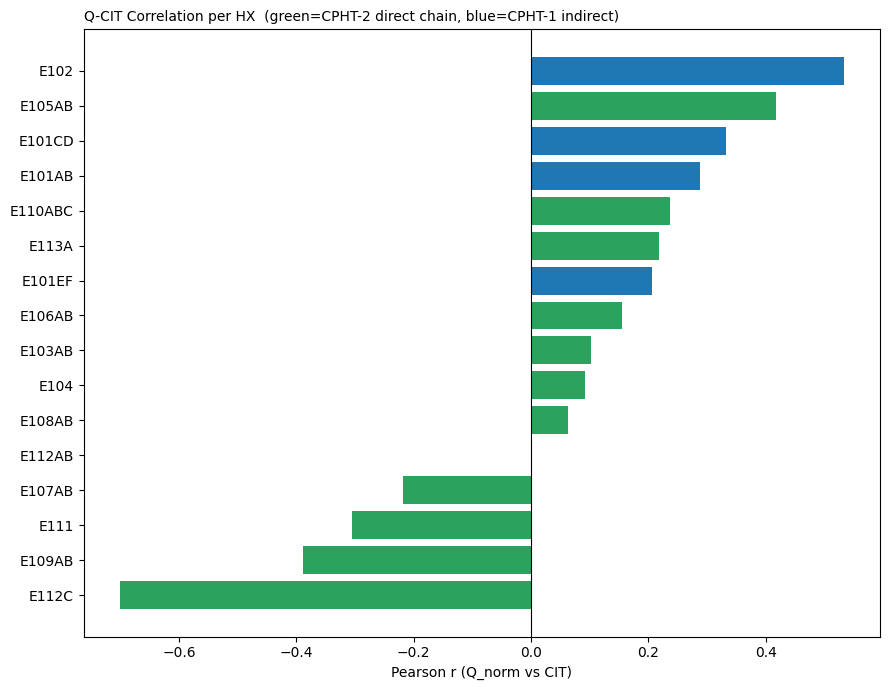

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in corr_df['group']]
ax.barh(corr_df['HX'], corr_df['Q_CIT_corr'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r (Q_norm vs CIT)')
ax.set_title('Q-CIT Correlation per HX  (green=CPHT-2 direct chain, blue=CPHT-1 indirect)',
             fontsize=10, loc='left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_correlation.png'), bbox_inches='tight')
plt.show()

---
## 2. Regression Slope -- CIT Sensitivity per HX

`CIT ~ a + b * Q_norm[hx]`, fit independently per HX (simple linear
regression, not multivariate — collinearity between CPHT-2 members' Q_norm
values would make individually-fit slopes unstable in a joint model with this
much shared variance). `b` [degC per unit Q_norm] is the sensitivity used
downstream for expected-CIT-gain estimates.

In [6]:
sens_rows = []
for hx in Q_norm_df.columns:
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    if len(joint) < 30:
        continue
    slope, intercept = np.polyfit(joint['Q'], joint['CIT'], 1)
    r = joint['Q'].corr(joint['CIT'])
    sens_rows.append({
        'HX': hx,
        'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
        'CIT_sensitivity_degC_per_Qnorm': round(slope, 3),
        'Q_CIT_corr': round(r, 4),
        'Q_norm_std': round(joint['Q'].std(), 3),
        'implied_degC_per_1std_Q': round(slope * joint['Q'].std(), 2),
    })

sens_df = pd.DataFrame(sens_rows).sort_values('implied_degC_per_1std_Q', ascending=False).reset_index(drop=True)
sens_df

,HX,group,CIT_sensitivity_degC_per_Qnorm,Q_CIT_corr,Q_norm_std,implied_degC_per_1std_Q
0,E102,CPHT-1,6.872,0.5333,0.462,3.17
1,E105AB,CPHT-2,1.418,0.4169,1.749,2.48
2,E101CD,CPHT-1,1.789,0.3327,1.106,1.98
3,E101AB,CPHT-1,1.231,0.2885,1.394,1.72
4,E110ABC,CPHT-2,0.312,0.2375,4.525,1.41
5,E101EF,CPHT-1,1.905,0.2058,0.671,1.28
6,E113A,CPHT-2,0.056,0.2191,22.741,1.28
7,E106AB,CPHT-2,0.280,0.1548,3.283,0.92
8,E103AB,CPHT-2,0.118,0.1025,5.148,0.61
9,E104,CPHT-2,0.467,0.0929,1.184,0.55


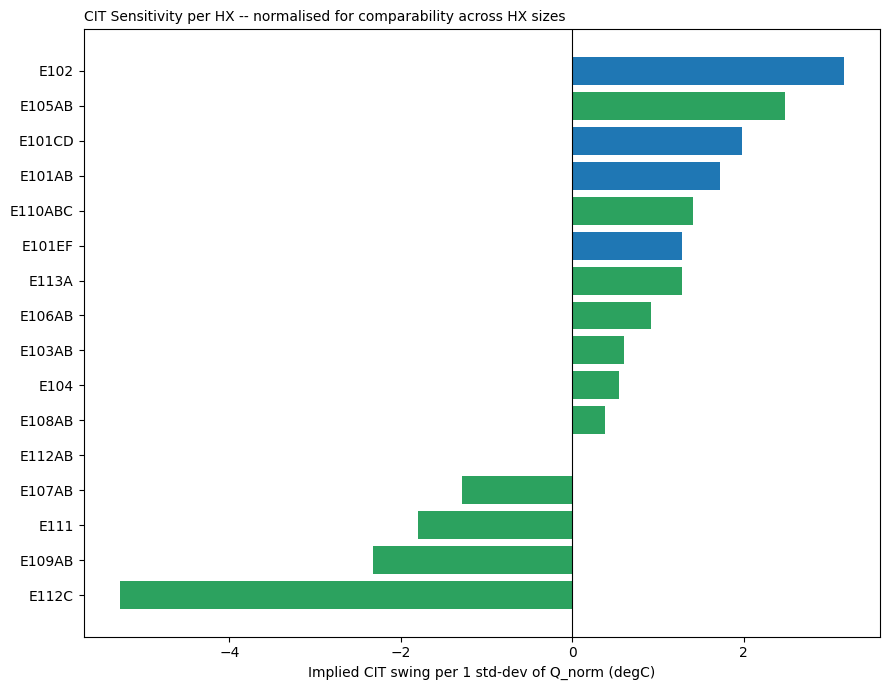

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in sens_df['group']]
ax.barh(sens_df['HX'], sens_df['implied_degC_per_1std_Q'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Implied CIT swing per 1 std-dev of Q_norm (degC)')
ax.set_title('CIT Sensitivity per HX -- normalised for comparability across HX sizes',
             fontsize=10, loc='left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_CIT_sensitivity.png'), bbox_inches='tight')
plt.show()

---
## 3. Scatter -- All HX

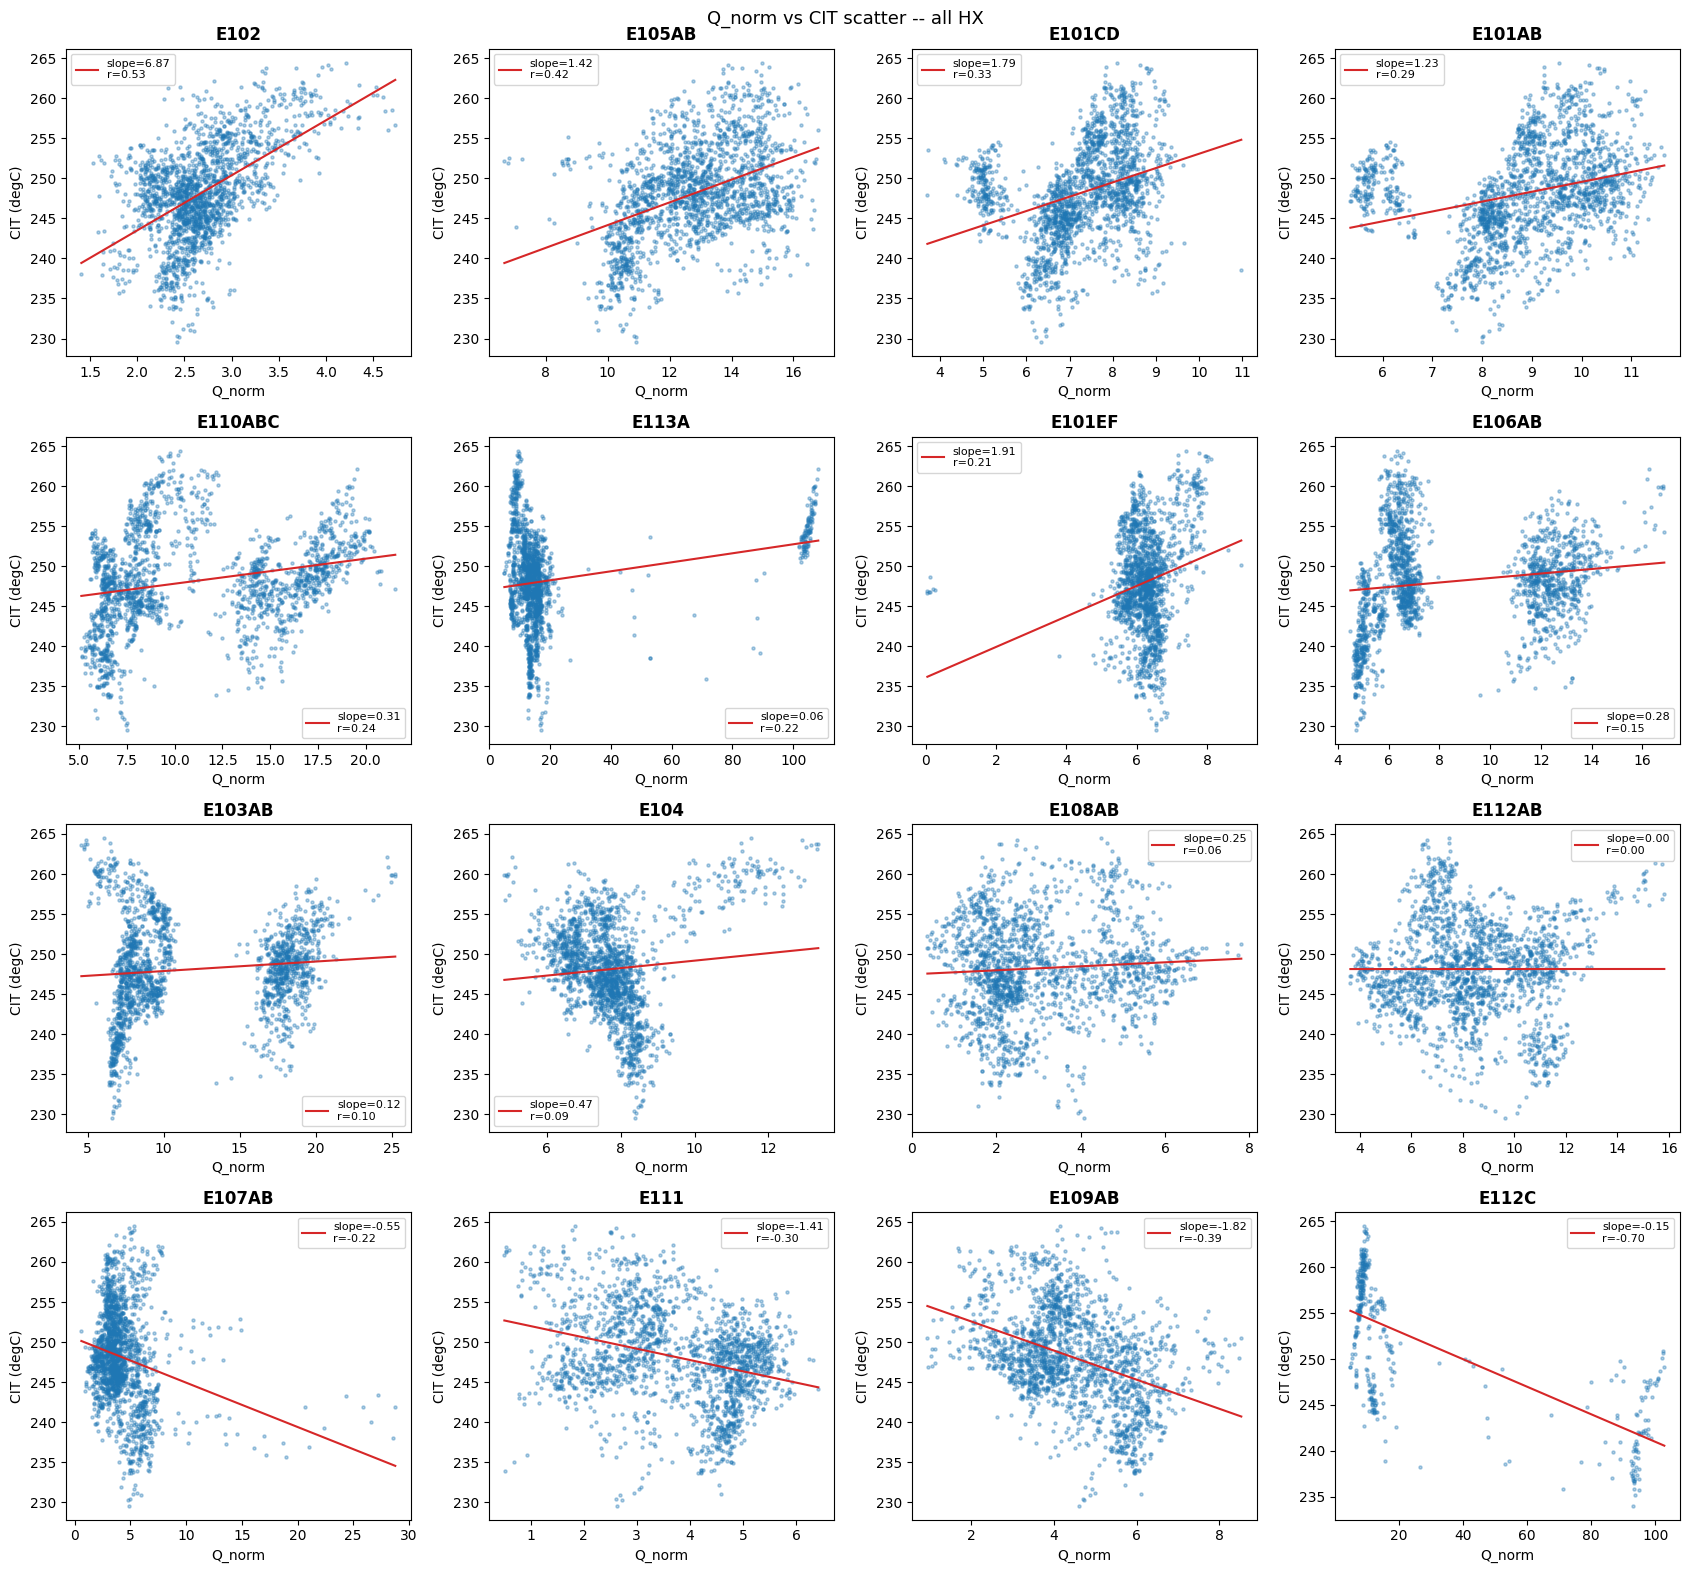

In [8]:
all_hx = corr_df['HX'].tolist()
n = len(all_hx)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows))
axes = axes.flatten()

for ax, hx in zip(axes, all_hx):
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    ax.scatter(joint['Q'], joint['CIT'], s=5, alpha=0.35, color='tab:blue')
    m, b = np.polyfit(joint['Q'], joint['CIT'], 1)
    xr = np.linspace(joint['Q'].min(), joint['Q'].max(), 100)
    ax.plot(xr, m * xr + b, color='tab:red', lw=1.5,
            label=f'slope={m:.2f}\nr={joint["Q"].corr(joint["CIT"]):.2f}')
    ax.set_xlabel('Q_norm')
    ax.set_ylabel('CIT (degC)')
    ax.set_title(hx, fontweight='bold')
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Q_norm vs CIT scatter -- all HX', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_scatter.png'), bbox_inches='tight')
plt.show()

---
## 3.1 Cold-Side Network Diagnostics -- Branch Heat Recovery and Compensation

The per-HX scatter above treats every exchanger independently, although the crude side is a
network. These diagnostics therefore aggregate `Q_norm` along each CPHT-2 crude branch, select
only the active final-position exchanger (`E113A` or `E112C`, never their sum), and inspect
day-to-day upstream/downstream compensation. All quantities remain **cold-side** duty divided
by total charge. These plots are diagnostics, not causal cleaning-gain estimates.


In [ ]:
# CPHT-2 cold-side crude branches from src.domain.config tag/predecessor topology.
# Require every member of a branch to be valid on the same date before summing, so a
# missing/offline exchanger cannot silently look like zero recovered heat.
NETWORK_BRANCHES = {
    'Branch A: E103-E104-E105': ['E103AB', 'E104', 'E105AB'],
    'Branch B: E106-E107-E108-E109': ['E106AB', 'E107AB', 'E108AB', 'E109AB'],
    'Branch C: E110-E111-E112': ['E110ABC', 'E111', 'E112AB'],
}

branch_qnorm = pd.DataFrame(index=Q_norm_df.index)
for branch, hxes in NETWORK_BRANCHES.items():
    branch_qnorm[branch] = Q_norm_df[hxes].sum(axis=1, min_count=len(hxes))

# E113A and E112C are alternate shells at the same final crude-side position.
# Feature_Q.csv is operating-state gated, so combine_first selects whichever shell is active.
final_qnorm = Q_norm_df['E113A'].combine_first(Q_norm_df['E112C']).rename('Final: E113A/E112C')
network_qnorm = pd.concat([branch_qnorm, final_qnorm], axis=1)
network_qnorm['CPHT-2 network total'] = network_qnorm.sum(axis=1, min_count=4)

def _scatter_with_fit(ax, x, y, title, color='tab:blue'):
    joint = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    ax.scatter(joint['x'], joint['y'], s=6, alpha=0.28, color=color)
    if len(joint) >= 3 and joint['x'].nunique() > 1:
        m, b = np.polyfit(joint['x'], joint['y'], 1)
        xr = np.linspace(joint['x'].min(), joint['x'].max(), 100)
        r = joint['x'].corr(joint['y'])
        ax.plot(xr, m * xr + b, color='tab:red', lw=1.4,
                label=f'slope={m:.2f} | r={r:.2f} | n={len(joint)}')
        ax.legend(fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cold-side Q_norm (kW per m3/h total charge)')
    ax.set_ylabel('CIT (degC)')
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, col in zip(axes.flat[:3], branch_qnorm.columns):
    _scatter_with_fit(ax, branch_qnorm[col], cit, col)
_scatter_with_fit(axes.flat[3], network_qnorm['CPHT-2 network total'], cit,
                  'CPHT-2 branch sums + active final position', color='tab:green')
fig.suptitle('Cold-side network Q_norm vs CIT -- branch and CPHT-2 aggregate', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_network_Q_CIT_scatter.png'), bbox_inches='tight')
plt.show()

network_qnorm.corrwith(cit).rename('Q_CIT_corr').to_frame().round(3)


In [ ]:
# First differences remove slow campaign/regime level shifts. If upstream dQ is negative
# while the downstream terminal dQ is positive, the downstream HX is locally compensating
# for lost upstream cold-side heat recovery.
COMPENSATION_PATHS = {
    'A: (E103+E104) -> E105': (['E103AB', 'E104'], 'E105AB'),
    'B: (E106+E107+E108) -> E109': (['E106AB', 'E107AB', 'E108AB'], 'E109AB'),
    'C: (E110+E111) -> E112': (['E110ABC', 'E111'], 'E112AB'),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
comp_rows = []
for ax, (label, (upstream_hx, downstream_hx)) in zip(axes, COMPENSATION_PATHS.items()):
    upstream = Q_norm_df[upstream_hx].sum(axis=1, min_count=len(upstream_hx))
    joint = pd.concat([upstream.diff().rename('dQ_up'),
                       Q_norm_df[downstream_hx].diff().rename('dQ_down'),
                       cit.rename('CIT')], axis=1).dropna()
    sc = ax.scatter(joint['dQ_up'], joint['dQ_down'], c=joint['CIT'], cmap='viridis',
                    s=7, alpha=0.35)
    ax.axhline(0, color='0.55', lw=0.8)
    ax.axvline(0, color='0.55', lw=0.8)
    r = joint['dQ_up'].corr(joint['dQ_down'])
    compensation_share = ((joint['dQ_up'] < 0) & (joint['dQ_down'] > 0)).mean()
    ax.set_title(f'{label}\nr={r:.2f} | compensation={compensation_share:.1%}',
                 fontweight='bold', fontsize=9.5, pad=9)
    ax.set_xlabel('Day-to-day upstream dQ_norm')
    ax.set_ylabel(f'Day-to-day {downstream_hx} dQ_norm')
    ax.grid(alpha=0.2)
    comp_rows.append({'path': label, 'dQ_corr': r,
                      'compensation_quadrant_share': compensation_share, 'n_days': len(joint)})
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
fig.colorbar(sc, cax=cbar_ax, label='CIT (degC)')
fig.suptitle('Cold-side upstream/downstream compensation -- day-to-day changes',
             fontsize=13, y=1.03)
plt.subplots_adjust(top=0.80, right=0.88, wspace=0.32)
plt.savefig(os.path.join(FIG_DIR, '2c_network_compensation.png'), bbox_inches='tight')
plt.show()

pd.DataFrame(comp_rows).round(3)


In [ ]:
# Compare level correlation with day-to-day correlation. A sign flip indicates that the
# full-period line is dominated by slow regime/campaign shifts rather than daily co-movement.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
diff_rows = []
for ax, col in zip(axes.flat, network_qnorm.columns):
    d_q = network_qnorm[col].diff()
    d_cit = cit.diff()
    _scatter_with_fit(ax, d_q, d_cit, f'Day-to-day: {col}', color='tab:orange')
    level_joint = pd.concat([network_qnorm[col], cit], axis=1).dropna()
    diff_joint = pd.concat([d_q, d_cit], axis=1).dropna()
    level_r = level_joint.iloc[:, 0].corr(level_joint.iloc[:, 1])
    diff_r = diff_joint.iloc[:, 0].corr(diff_joint.iloc[:, 1])
    diff_rows.append({'network_component': col, 'level_r': level_r, 'difference_r': diff_r,
                      'sign_flip': np.sign(level_r) != np.sign(diff_r), 'n_days': len(diff_joint)})
fig.suptitle('Day-to-day cold-side network Q_norm change vs CIT change', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_network_dQ_dCIT.png'), bbox_inches='tight')
plt.show()

pd.DataFrame(diff_rows).round(3)


---
## 4. Rolling Correlation -- Is Any HX Becoming More Critical?

A HX whose Q-CIT correlation strengthens over time is becoming an increasingly
dominant driver of CIT (e.g. as other HX get cleaned and stop varying, or as
this one's fouling range widens).

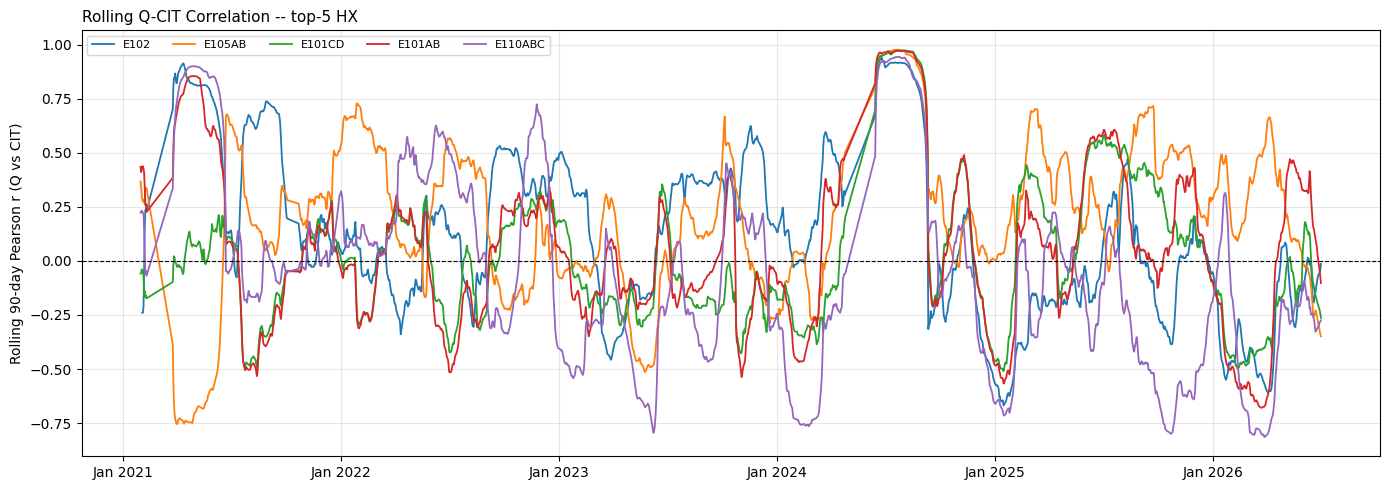

In [9]:
top5_hx = corr_df.head(5)['HX'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
for hx in top5_hx:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    roll_r = joint.iloc[:, 0].rolling(90, min_periods=30).corr(joint.iloc[:, 1])
    ax.plot(roll_r.index, roll_r, lw=1.3, label=hx)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Rolling 90-day Pearson r (Q vs CIT)')
ax.set_title('Rolling Q-CIT Correlation -- top-5 HX', fontsize=11, loc='left')
ax.legend(ncol=5, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_Q_CIT_rolling_corr.png'), bbox_inches='tight')
plt.show()

---
## 5. Export

`Q_CIT_Sensitivity.csv` -- one row per HX: correlation + regression slope,
feeding directly into `2d`'s expected-CIT-gain calculation.

In [10]:
sens_export = sens_df.merge(corr_df[['HX', 'n_days']], on='HX', how='left')
sens_export.to_csv(DATA_DIR + r'\Q_CIT_Sensitivity.csv', index=False)
print('Wrote Q_CIT_Sensitivity.csv', sens_export.shape)
sens_export.round(4)

Wrote Q_CIT_Sensitivity.csv (16, 7)


,HX,group,CIT_sensitivity_degC_per_Qnorm,Q_CIT_corr,Q_norm_std,implied_degC_per_1std_Q,n_days
0,E102,CPHT-1,6.872,0.5333,0.462,3.17,1894
1,E105AB,CPHT-2,1.418,0.4169,1.749,2.48,1898
2,E101CD,CPHT-1,1.789,0.3327,1.106,1.98,1898
3,E101AB,CPHT-1,1.231,0.2885,1.394,1.72,1898
4,E110ABC,CPHT-2,0.312,0.2375,4.525,1.41,1898
5,E101EF,CPHT-1,1.905,0.2058,0.671,1.28,1697
6,E113A,CPHT-2,0.056,0.2191,22.741,1.28,1708
7,E106AB,CPHT-2,0.280,0.1548,3.283,0.92,1898
8,E103AB,CPHT-2,0.118,0.1025,5.148,0.61,1898
9,E104,CPHT-2,0.467,0.0929,1.184,0.55,1898


---
## 6. Cleaning Frequency & Time-to-Fouling per HX

**Revised again** -- the first cut (pure Q-jump signature, 90-day min
spacing) under-counted `E113A`/`E112C` specifically: engineer input says
`E113A` is cleaned often, but Q-jump-while-running only found 2-3 raw
events for it in 2.4 years. Reason: `E113A`/`E112C` are a parallel-shell
pair (`PARALLEL_SHELL_GROUPS`) -- their cleaning mechanism is an **offline
shell swap** (take one out, let the other carry duty, clean it, swap back),
which shows up as an `Operating_State.csv` transition back into
`NORMAL`/`SUBSTITUTE_ACTIVE`, not as an online duty-recovery jump. For every
other HX (no swap partner), the Q-jump signature is still the only
available cleaning signature.

So the count below is, per HX:
- **Q-jump recovery** (duty jumps up while running) -- for all HX
- **+ state-transition-into-active** (from `2a`) -- for `E113A`/`E112C` only,
  since a swap-back is a real clean and would otherwise be invisible here
- **45-day minimum spacing** between counted events (down from 90d, which
  was too coarse -- 45d still collapses same-event noise without erasing
  distinct swap cycles, which run ~2-6 months apart in this data)

**Time-to-threshold now carries a confidence tag.** `2b` fits the fouling
slope on the *after-initiation phase only* (skips the first 15 days of
each campaign, aligned with `02_feature_engineering.ipynb`'s
`FOULING_LAG_DAYS`) and reports `median_R2` alongside the rate. A
projection built on a low-R² slope (noisy/unstable trend) is much less
trustworthy than one with a clean linear fit, even if the point estimate
looks similar -- `rate_confidence` below makes that visible instead of
presenting every HX's projection with equal authority.

In [ ]:
fouling_rank_df = pd.read_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv')
state = pd.read_csv(OPERATING_STATE_CSV, index_col=0, parse_dates=True)

# Shared with notebook 02 -- single source of truth in src/domain/event_thresholds.py.
# 2026-07-20 fix: this cell used to carry its own TAM_FLOW_THRESH = 200.0, silently
# disagreeing with notebook 02's engineering-justified 50 m3/h (both read the same
# TOTAL_CHARGE_TAG). In practice total charge never drops below ~360 m3/h in this
# dataset -- TAM periods show up as missing rows, not low-flow rows -- so the stale
# 200 never actually mis-fired here, but it would on any dataset where a TAM shows
# up as genuinely low flow instead of a data gap. See event_thresholds.py's docstring.
from src.domain.event_thresholds import SWITCH_JUMP_FRAC, SWITCH_SMOOTH_WIN, TAM_FLOW_THRESH

# Intentionally NOT shared with notebook 02's EVENT_DEDUP_DAYS (=7): this notebook's
# cleaning-event signal (qjump_dates, an online Q-duty recovery jump) is noisier than
# notebook 02's physical U-jump detector, so it needs a wider merge window to avoid
# double-counting one real clean as several nearby detections.
MIN_CLEAN_INTERVAL_DAYS = 45  # collapses noise-driven repeat detections, keeps distinct swap cycles
CLEAN_THRESHOLD_PCT = 30.0    # duty-drop trigger used for the time-to-fouling projection
VALID_STATES = {'NORMAL', 'SUBSTITUTE_ACTIVE'}
SWAP_CAPABLE_HX = {hx for pair in PARALLEL_SHELL_GROUPS for hx in pair}
R2_HIGH, R2_MODERATE = 0.5, 0.3   # same "steady trend" bar 02_feature_engineering uses

total_flow = df[TOTAL_CHARGE_TAG]
plant_running = total_flow > TAM_FLOW_THRESH
span_years = (Q_norm_df.index.max() - Q_norm_df.index.min()).days / 365

def qjump_dates(hx):
    """Online duty-recovery signature -- the only cleaning signal available
    for HX with no parallel-shell spare."""
    q = Q_norm_df[hx]
    q_smooth = q.rolling(SWITCH_SMOOTH_WIN, min_periods=2).mean()
    jump = q_smooth.diff()
    jump_thresh = SWITCH_JUMP_FRAC * q.median()
    return set(d for d in jump[(jump > jump_thresh) & plant_running].index if pd.notna(d))

def state_swap_back_dates(hx):
    """Offline shell-swap-back signature -- only meaningful for parallel-shell
    HX, where taking the unit out and swapping back in IS the clean."""
    if hx not in state.columns:
        return set()
    s = state[hx]
    changed = s != s.shift(1)
    into_active = changed & s.isin(VALID_STATES)
    return set(d for d in s.index[into_active] if d != s.index[0])  # drop data-start row

def necessary_cleanings_for_hx(hx):
    candidates = qjump_dates(hx)
    if hx in SWAP_CAPABLE_HX:
        candidates |= state_swap_back_dates(hx)
    candidates = sorted(candidates)

    deduped, last = [], None
    for d in candidates:
        if last is None or (d - last).days > MIN_CLEAN_INTERVAL_DAYS:
            deduped.append(d)
            last = d
    return deduped

cleaning_events = {hx: necessary_cleanings_for_hx(hx) for hx in Q_norm_df.columns}
n_cleanings = pd.Series({hx: len(v) for hx, v in cleaning_events.items()}, name='n_cleanings_necessary')

def days_to_threshold(rate_pct_per_30d, active, threshold_pct=CLEAN_THRESHOLD_PCT):
    if not active or pd.isna(rate_pct_per_30d) or rate_pct_per_30d >= 0:
        return np.nan
    return threshold_pct / abs(rate_pct_per_30d) * 30

def rate_confidence(r2):
    if pd.isna(r2):
        return 'unknown'
    if r2 >= R2_HIGH:
        return 'high'
    if r2 >= R2_MODERATE:
        return 'moderate'
    return 'low'

clean_summary = fouling_rank_df.merge(n_cleanings.rename('n_cleanings_necessary'), on=None,
                                       left_on='HX', right_index=True, how='left')
clean_summary['cleanings_per_year'] = (clean_summary['n_cleanings_necessary'] / span_years).round(2)
clean_summary['est_days_to_30pct_drop'] = clean_summary.apply(
    lambda row: days_to_threshold(row['median_pct_drop_per_30d'], row['currently_active']), axis=1)
clean_summary['rate_confidence'] = clean_summary['median_R2'].apply(rate_confidence)

clean_summary = clean_summary.sort_values('median_pct_drop_per_30d').reset_index(drop=True)
cols = ['HX', 'group', 'n_cleanings_necessary', 'cleanings_per_year', 'median_pct_drop_per_30d',
        'median_R2', 'rate_confidence', 'est_days_to_30pct_drop', 'currently_active']
print('n_cleanings_necessary = Q-jump recovery (all HX) + state swap-back (E113A/E112C only), 45-day min spacing.')
print('Negative median_pct_drop_per_30d = fouling; est_days_to_30pct_drop is NaN for '
      'flat/improving or currently-inactive HX (projection not meaningful there).')
print(f'rate_confidence: high (R2>={R2_HIGH}) / moderate (R2>={R2_MODERATE}) / low -- '
      'trust the day-estimate accordingly, especially for "low".')
clean_summary[cols].round(2)

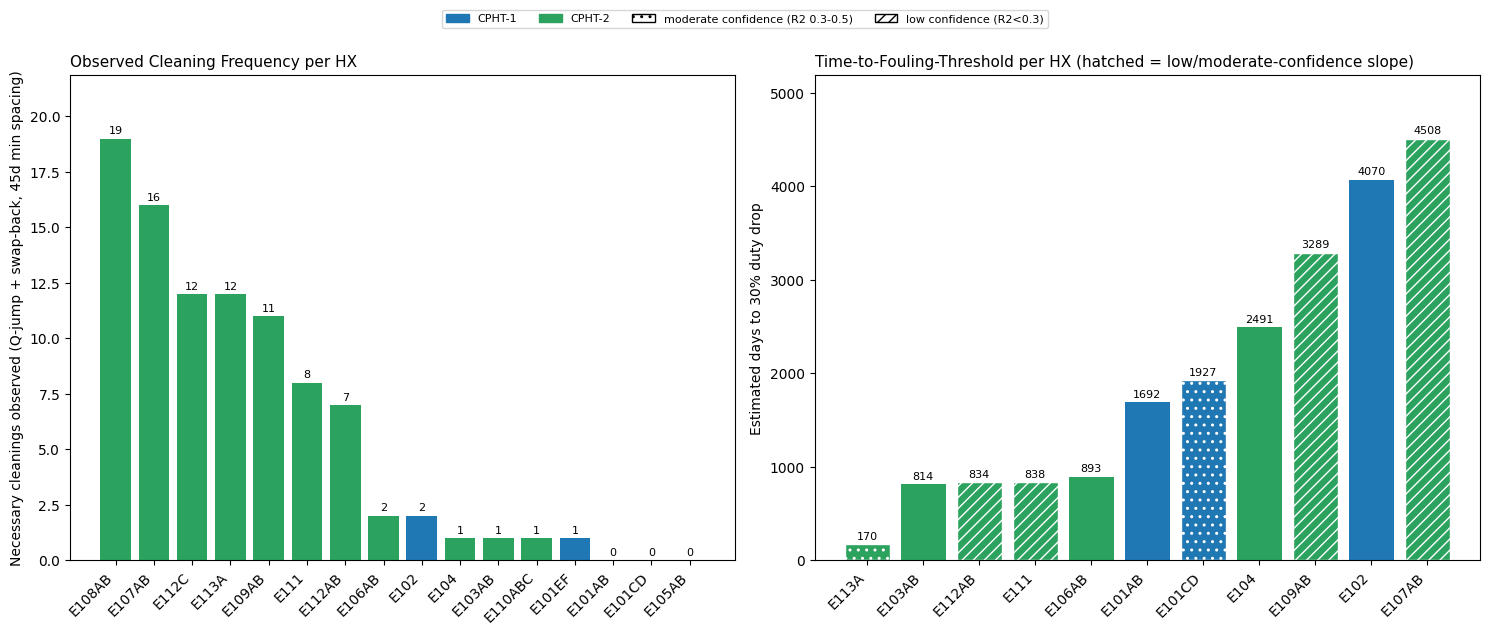

In [12]:
plot_df = clean_summary.sort_values('n_cleanings_necessary', ascending=False).reset_index(drop=True)
colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in plot_df['group']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars0 = axes[0].bar(plot_df['HX'], plot_df['n_cleanings_necessary'], color=colors)
axes[0].bar_label(bars0, fmt='%.0f', fontsize=8, padding=2)
axes[0].set_ylabel('Necessary cleanings observed (Q-jump + swap-back, 45d min spacing)')
axes[0].set_title('Observed Cleaning Frequency per HX', fontsize=11, loc='left')
axes[0].set_xticks(range(len(plot_df)))
axes[0].set_xticklabels(plot_df['HX'], rotation=45, ha='right')
axes[0].margins(y=0.15)

rate_df = clean_summary.dropna(subset=['est_days_to_30pct_drop']).sort_values('est_days_to_30pct_drop')
bar_colors = ['#2ca25f' if g == 'CPHT-2' else '#1f77b4' for g in rate_df['group']]
bars1 = axes[1].bar(rate_df['HX'], rate_df['est_days_to_30pct_drop'], color=bar_colors)
# Hatch low-confidence (noisy-slope) projections instead of presenting them at face value
for bar, conf in zip(bars1, rate_df['rate_confidence']):
    if conf == 'low':
        bar.set_hatch('///')
        bar.set_edgecolor('white')
    elif conf == 'moderate':
        bar.set_hatch('..')
        bar.set_edgecolor('white')
axes[1].bar_label(bars1, fmt='%.0f', fontsize=8, padding=2)
axes[1].set_ylabel('Estimated days to 30% duty drop')
axes[1].set_title('Time-to-Fouling-Threshold per HX (hatched = low/moderate-confidence slope)',
                   fontsize=11, loc='left')
axes[1].set_xticks(range(len(rate_df)))
axes[1].set_xticklabels(rate_df['HX'], rotation=45, ha='right')
axes[1].margins(y=0.15)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#1f77b4', '#2ca25f']]
handles += [plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black', hatch=h)
            for h in ['..', '///']]
labels = ['CPHT-1', 'CPHT-2', 'moderate confidence (R2 0.3-0.5)', 'low confidence (R2<0.3)']
fig.legend(handles, labels, fontsize=8, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2c_cleaning_frequency_and_ttf.png'), bbox_inches='tight')
plt.show()

---

## 7. Cleaning Event Impact: Q & CIT Before/After (per HX)

Per-HX view of `Q_norm` alongside plant CIT, with a shaded band around each
cleaning event, to show the jump this analysis is claiming. Event dates are
**not** re-derived from `Q_norm` here -- they come straight from
`Fouling_Rate_By_Run.csv` (`Run_start` where `Start_event` is `TAM` or
`SWITCH`), the same event list notebook 02 / `pipeline/compute_fouling_rate.py`
already computed from the physical U-jump detector. Re-deriving a second,
independent "when was this cleaned" definition from `Q_norm` here would
contradict the point of unifying the two notebooks' event logic above.

**Caveat:** CIT is a single plant-level tag driven by all 16 HX plus crude
quality and ambient conditions -- a before/after CIT delta at one HX's
cleaning event is **not** an isolated causal estimate of that HX's
contribution (section 1.1 above already partial-correlation-controls for the
biggest confound, total charge rate). Treat the CIT panel here as
illustrative context for the Q jump, not a standalone effect size.

TAM-only HX (no spare shell to swap online -- E101AB/E101EF/E103AB/E106AB/E107AB/E109AB/E110ABC) only have TAM boundaries as events, and the data itself has no rows during a TAM shutdown (confirmed separately: those days are missing from `Process_information_with_crude.csv` entirely, not just low-flow). A short before/after window can therefore land fully inside that gap and come back `NaN` -- that is honest missing-data behavior, not a bug to paper over.


In [ ]:
from src.domain.event_thresholds import EVENT_DEDUP_DAYS

# Canonical cleaning-event dates -- same source as notebook 02 (Fouling_Rate_By_Run.csv),
# not re-derived from Q_norm here. Run 1 per HX is always 'DATA_START', not a real event.
rf_by_run_events = pd.read_csv(DATA_DIR + r'\Fouling_Rate_By_Run.csv', parse_dates=['Run_start'])
rf_by_run_events = rf_by_run_events[rf_by_run_events['Start_event'].isin(['TAM', 'SWITCH'])]

WINDOW_DAYS = EVENT_DEDUP_DAYS  # +/- window for the before/after comparison and the shaded band
hx_list = [hx for hx in Q_norm_df.columns if hx in rf_by_run_events['HX'].unique()]

n_cols = 4
n_rows = int(np.ceil(len(hx_list) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows), sharex=False)
axes = axes.flatten()

impact_rows = []
for ax, hx in zip(axes, hx_list):
    q = Q_norm_df[hx].dropna()
    events = rf_by_run_events.loc[rf_by_run_events['HX'] == hx, 'Run_start'].sort_values()

    ax.plot(q.index, q.values, color='tab:blue', lw=0.8)
    ax2 = ax.twinx()
    ax2.plot(cit.index, cit.values, color='tab:red', lw=0.6, alpha=0.6)

    for ev in events:
        ax.axvspan(ev - pd.Timedelta(days=WINDOW_DAYS), ev + pd.Timedelta(days=WINDOW_DAYS),
                   color='#9467bd', alpha=0.20, lw=0)
        q_before = q[(q.index >= ev - pd.Timedelta(days=WINDOW_DAYS)) & (q.index < ev)].mean()
        q_after = q[(q.index > ev) & (q.index <= ev + pd.Timedelta(days=WINDOW_DAYS))].mean()
        cit_before = cit[(cit.index >= ev - pd.Timedelta(days=WINDOW_DAYS)) & (cit.index < ev)].mean()
        cit_after = cit[(cit.index > ev) & (cit.index <= ev + pd.Timedelta(days=WINDOW_DAYS))].mean()
        impact_rows.append({'HX': hx, 'event_date': ev, 'Q_before': q_before, 'Q_after': q_after,
                             'dQ': q_after - q_before, 'CIT_before': cit_before, 'CIT_after': cit_after,
                             'dCIT': cit_after - cit_before})

    ax.set_title(hx, fontsize=9)
    ax.tick_params(labelsize=6)
    ax2.tick_params(labelsize=6)

for ax in axes[len(hx_list):]:
    ax.axis('off')

q_line = plt.Line2D([0], [0], color='tab:blue', lw=1.5, label='Q_norm (this HX, left axis)')
cit_line = plt.Line2D([0], [0], color='tab:red', lw=1.5, label='CIT (plant, right axis)')
band_patch = plt.Rectangle((0, 0), 1, 1, color='#9467bd', alpha=0.20,
                            label=f'cleaning event window (±{WINDOW_DAYS}d)')
fig.legend(handles=[q_line, cit_line, band_patch], loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Cleaning Event Impact per HX — Q_norm & plant CIT before/after '
             '(purple band = event window)', y=1.04)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '2c_cleaning_impact_Q_CIT.png'),
            dpi=130, bbox_inches='tight')
plt.show()

impact_df = pd.DataFrame(impact_rows)
impact_df['dQ_pct'] = (impact_df['dQ'] / impact_df['Q_before'] * 100).round(1)
impact_df.to_csv(DATA_DIR + r'\Cleaning_Impact_Summary.csv', index=False)
print(f'Wrote Cleaning_Impact_Summary.csv: {impact_df.shape}')
impact_df.groupby('HX')[['dQ', 'dQ_pct', 'dCIT']].mean().round(2).sort_values('dQ_pct')


---

## 8. Cleaning Event Deep-Dive: CIT / ΔT / Rf per HX

Same 3-panel layout as notebook 02's per-HX profile dashboard (section 3.12: CIT / ΔT /
Rf stacked, TAM=black dotted line, SWITCH=purple dashed line), extended with two things
notebook 02 doesn't do together in one view:

- a light-blue shaded band over each event's before/after comparison window, using the
  **same window definition as notebook 02 section 3.7e's Event Impact Analysis**
  (`BEFORE_DAYS=14`, `AFTER_DAYS=14`, a `15`-day post-event lag matching notebook 02's
  `FOULING_LAG_DAYS`) -- kept as local constants here rather than another
  `event_thresholds.py` entry, since this is a diagnostic comparison window, not an
  event-*detection* threshold.
- numeric ΔQ / ΔCIT labels annotated directly on the CIT panel at each event, not just
  the event line.

Event dates come straight from `Feature_calculated.csv`'s own per-HX `run_id` /
`event_type` / `days_on_duty` columns -- the exact run boundaries notebook 02 /
`pipeline/compute_fouling_rate.py` already computed -- not re-detected here.


In [ ]:
from src.domain.config import HX_CONFIG as HX_CONFIG_COLD
from src.features.heat_duty import HX_CONFIG as _FULL_CFG, parse_hx as _parse_hx
HOT_TAGS = {hx: _parse_hx(cfg) for hx, cfg in _FULL_CFG.items()}
# Note: E112AB's hot_in here is the single static tag ('1TI117.pv'), not the dynamic
# max(E113A_hot_out, E112C_hot_out) used elsewhere for its Q/Rf calculation (see notebook
# 02 section 7) -- acceptable for this diagnostic dT view, same approximation this
# notebook's own Part 2 (section 2, cell "Build Pooled Training Set") already makes.

feat_ts = pd.read_csv(DATA_DIR + r'\Feature_calculated.csv', parse_dates=['Timestamp']).set_index('Timestamp')

# Same before/after window as notebook 02 section 3.7e's Event Impact Analysis.
BEFORE_DAYS = 14
AFTER_DAYS = 14
DEEPDIVE_LAG_DAYS = 15   # matches notebook 02 section 3.6's FOULING_LAG_DAYS
MIN_EVENT_PTS = 5

EVENT_LINE_STYLE = {'TAM': dict(color='black', linestyle=':'), 'SWITCH': dict(color='purple', linestyle='--')}


def hx_event_starts(hx):
    """(date, event_type) for every real event boundary, straight from
    Feature_calculated.csv's own run_id/event_type/days_on_duty -- the exact run
    boundaries notebook 02 / pipeline/compute_fouling_rate.py already computed,
    not re-detected here."""
    et = feat_ts[f'{hx}_event_type']
    dod = feat_ts[f'{hx}_days_on_duty']
    starts = feat_ts.index[(dod == 0) & et.isin(['TAM', 'SWITCH'])]
    return [(d, et.loc[d]) for d in starts]


DEEPDIVE_DIR = os.path.join(FIG_DIR, 'cleaning_deepdive')
os.makedirs(DEEPDIVE_DIR, exist_ok=True)

deepdive_rows = []
for hx in HX_CONFIG_COLD:
    cold_cfg = HX_CONFIG_COLD[hx]
    hot_cfg = HOT_TAGS[hx]
    dt_cold = feat_ts[cold_cfg['cold_out']] - feat_ts[cold_cfg['cold_in']]
    dt_hot = feat_ts[hot_cfg['hot_in']] - feat_ts[hot_cfg['hot_out']]
    rf = feat_ts[f'{hx}_Rf_run']
    q_hx = feat_ts[f'{hx}_Q']
    events = hx_event_starts(hx)

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(cit.index, cit.values, color='#d62728', linewidth=0.9)
    axes[0].set_ylabel('degC')
    axes[0].set_title(f'CIT ({CIT_TAG})', fontsize=10, loc='left')

    axes[1].plot(dt_cold.index, dt_cold, color='#2ca02c', linewidth=0.8, label='dT_cold')
    axes[1].plot(dt_hot.index, dt_hot, color='#ff7f0e', linewidth=0.8, label='dT_hot')
    axes[1].set_ylabel('degC')
    axes[1].set_title(f'{hx} — dT Cold/Hot', fontsize=10, loc='left')
    axes[1].legend(fontsize=8, loc='best')

    rf_s = rf.rolling(7, min_periods=3, center=True).mean()
    axes[2].plot(rf.index, rf, color='#f4a582', linewidth=0.4, alpha=0.5)
    axes[2].plot(rf_s.index, rf_s, color='#d62728', linewidth=0.9, label='Rf (7d avg)')
    axes[2].axhline(0.0, color='#2ca25f', linewidth=0.8, linestyle='--', alpha=0.7)
    axes[2].set_ylabel('Rf (m2K/W)')
    axes[2].set_title(f'{hx} — Fouling Rate (Rf_run)', fontsize=10, loc='left')
    axes[2].legend(fontsize=8, loc='best')

    for ev_date, ev_type in events:
        before_start = ev_date - pd.Timedelta(days=BEFORE_DAYS)
        after_start = ev_date + pd.Timedelta(days=DEEPDIVE_LAG_DAYS)
        after_end = after_start + pd.Timedelta(days=AFTER_DAYS)

        style = EVENT_LINE_STYLE.get(ev_type, dict(color='gray', linestyle='-'))
        for ax in axes:
            ax.axvspan(before_start, after_end, color='#6baed6', alpha=0.18, lw=0)
            ax.axvline(ev_date, linewidth=1.0, alpha=0.7, **style)

        before_mask = (feat_ts.index >= before_start) & (feat_ts.index < ev_date)
        after_mask = (feat_ts.index >= after_start) & (feat_ts.index < after_end)
        n_before, n_after = int(before_mask.sum()), int(after_mask.sum())
        if n_before < MIN_EVENT_PTS or n_after < MIN_EVENT_PTS:
            continue

        cit_before, cit_after = cit[before_mask].mean(), cit[after_mask].mean()
        q_before, q_after = q_hx[before_mask].mean(), q_hx[after_mask].mean()
        d_cit, d_q = cit_after - cit_before, q_after - q_before

        label = f'{ev_type}\ndQ={d_q:+.0f}kW\ndCIT={d_cit:+.1f}C'
        axes[0].annotate(label, (ev_date, cit.max()), fontsize=6.5, ha='center', va='top',
                          color=('#2ca25f' if d_cit >= 0 else '#d62728'))

        deepdive_rows.append(dict(
            HX=hx, Event_date=ev_date.date(), Event_type=ev_type,
            Q_before=round(float(q_before), 1), Q_after=round(float(q_after), 1), dQ=round(float(d_q), 1),
            CIT_before=round(float(cit_before), 2), CIT_after=round(float(cit_after), 2), dCIT=round(float(d_cit), 2),
        ))

    axes[-1].set_xlabel('Date')
    fig.suptitle(f'{hx} — Cleaning Event Deep-Dive: CIT / dT / Rf '
                 f'(blue band = before/after comparison window, dotted black=TAM, dashed purple=switch)',
                 fontsize=11, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(DEEPDIVE_DIR, f'{hx}_deepdive.png'), dpi=140, bbox_inches='tight')
    plt.show()
    plt.close(fig)

deepdive_df = pd.DataFrame(deepdive_rows)
deepdive_df.to_csv(DATA_DIR + r'\Cleaning_Event_Deepdive.csv', index=False)
print(f'Wrote Cleaning_Event_Deepdive.csv: {deepdive_df.shape}')
deepdive_df


### 8b. E113A / E112C Swap-Shell Operation

E113A and E112C are one physical train position with two shells (see
`PARALLEL_SHELL_GROUPS`) -- only one is on duty at a time (`NORMAL` for E113A /
`SUBSTITUTE_ACTIVE` for E112C), the other sits `SUBSTITUTED`/`OFF`. This stacks their
`Operating_State` against both HX's Rf_run and plant CIT so the swap cadence -- and its
effect -- is visible in one view, answering "how does this group actually operate."


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1, 2, 2]})

state_colors = {'NORMAL': '#2ca25f', 'SUBSTITUTE_ACTIVE': '#2ca25f',
                 'SUBSTITUTED': '#cccccc', 'OFF': '#cccccc',
                 'BYPASS_UPSTREAM_ACTIVE': '#feb24c'}

for ax, hx in zip(axes[:2], ['E113A', 'E112C']):
    s = state[hx]
    for st in s.dropna().unique():
        mask = (s == st).values
        ax.fill_between(s.index, 0, 1, where=mask, color=state_colors.get(st, '#999999'),
                         step='post', linewidth=0)
    ax.set_yticks([])
    ax.set_ylabel(hx, rotation=0, labelpad=30, fontsize=9)
    handles = [plt.Rectangle((0, 0), 1, 1, color=state_colors.get(st, '#999999')) for st in s.dropna().unique()]
    ax.legend(handles, s.dropna().unique(), fontsize=7, loc='upper right', ncol=len(s.dropna().unique()))

rf_e113a = feat_ts['E113A_Rf_run'].rolling(7, min_periods=3, center=True).mean()
rf_e112c = feat_ts['E112C_Rf_run'].rolling(7, min_periods=3, center=True).mean()
axes[2].plot(rf_e113a.index, rf_e113a, color='#1f77b4', linewidth=0.9, label='E113A Rf (7d avg)')
axes[2].plot(rf_e112c.index, rf_e112c, color='#e6550d', linewidth=0.9, label='E112C Rf (7d avg)')
axes[2].axhline(0, color='gray', linewidth=0.6)
axes[2].set_ylabel('Rf (m2K/W)')
axes[2].legend(fontsize=8)

axes[3].plot(cit.index, cit.values, color='#d62728', linewidth=0.9)
axes[3].set_ylabel('CIT (degC)')
axes[3].set_xlabel('Date')

swap_events = sorted(hx_event_starts('E113A') + hx_event_starts('E112C'), key=lambda x: x[0])
for ax in axes:
    for ev_date, ev_type in swap_events:
        style = EVENT_LINE_STYLE.get(ev_type, dict(color='gray', linestyle='-'))
        ax.axvline(ev_date, linewidth=0.8, alpha=0.5, **style)

fig.suptitle('E113A / E112C Swap-Shell Group: Active-Shell State, Rf, and Plant CIT '
             '(dotted black=TAM, dashed purple=switch)', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(DEEPDIVE_DIR, 'E113A_E112C_swap_operation.png'), dpi=140, bbox_inches='tight')
plt.show()


---

# Part 2 · Clean-Baseline Fouling-Rate Forecast (Pooled, Physics-Baseline ML on Duty)

*(merged from the former `04_clean_baseline.ipynb`, 2026-07-19 — content unchanged, only the
redundant DE-STEP-HEADER/title boilerplate was folded into this notebook's own header above.)*

**Purpose:** build a denser, operating-condition-aware fouling signal than the single per-run
slope used in Part 1's `Fouling_Rate_By_Run.csv`. This notebook adapts the methodology of two
reference works to this plant's sensor layout, and is the second stage of the
Part-1 -> Part-2 -> Part-3 pipeline: CIT sensitivity -> fouling-rate forecast -> time-to-clean
prediction.


In [13]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from src.domain.config import CPHT_1_HX, CPHT_2_HX, HX_CONFIG
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.dummy import DummyRegressor

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

feat = pd.read_csv(DATA_DIR + r'\Feature_calculated.csv', parse_dates=['Timestamp'])
op_state = pd.read_csv(DATA_DIR + r'\Operating_State.csv', parse_dates=['Timestamp'])
active_hx = pd.read_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv')

ALL_HX = list(HX_CONFIG.keys())
print(f'{len(ALL_HX)} HX with cold-side config: {ALL_HX}')
print(f'Feature_calculated.csv: {feat.shape}, {feat["Timestamp"].min().date()} to {feat["Timestamp"].max().date()}')

16 HX with cold-side config: ['E101AB', 'E101CD', 'E101EF', 'E102', 'E103AB', 'E104', 'E105AB', 'E106AB', 'E107AB', 'E108AB', 'E109AB', 'E110ABC', 'E111', 'E112AB', 'E112C', 'E113A']
Feature_calculated.csv: (1898, 397), 2021-01-01 to 2026-07-01


## 1. Static HX Features

Same chain-position / hot-end constants as `2d`, kept here so a pooled model
can use them as identity features (chain position substitutes for the
missing hot-side data -- HX further down the residue chain systematically
run cooler and inherit already-fouled upstream neighbours, both of which
shift the clean-state `cold_out` relationship).

In [14]:
HOT_END_THRESH_C = 220.0
RESIDUE_CHAIN_POSITION = {'E113A': 1, 'E112C': 1, 'E112AB': 2, 'E108AB': 3, 'E110ABC': 4}

temp_path = DATA_DIR + r'\Process_information_with_crude.csv'
df_temp = pd.read_csv(temp_path, index_col=0, parse_dates=True)

static_rows = []
for hx, cfg in HX_CONFIG.items():
    tag = cfg['cold_out']
    mean_cold_out = df_temp[tag].mean() if tag in df_temp.columns else np.nan
    static_rows.append({
        'HX': hx,
        'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
        'chain_position': RESIDUE_CHAIN_POSITION.get(hx, 0),
        'hot_end': int(mean_cold_out > HOT_END_THRESH_C) if not np.isnan(mean_cold_out) else 0,
    })
static_df = pd.DataFrame(static_rows)
static_df

,HX,group,chain_position,hot_end
0,E101AB,CPHT-1,0,0
1,E101CD,CPHT-1,0,0
2,E101EF,CPHT-1,0,0
3,E102,CPHT-1,0,0
4,E103AB,CPHT-2,0,0
5,E104,CPHT-2,0,0
6,E105AB,CPHT-2,0,1
7,E106AB,CPHT-2,0,0
8,E107AB,CPHT-2,0,0
9,E108AB,CPHT-2,3,0


## 2. Build Pooled Training Set (30-Day Post-Clean Windows)

For each HX: keep rows where `{HX}_days_on_duty <= 30` **and** the HX is
`NORMAL` in `Operating_State.csv` (drop rows where it's substituted/off, per
the same active-shell logic `2b`/`2d` use). `days_on_duty` itself is *not* a
model feature -- including it would let the model absorb the early-window
fouling trend into what's supposed to be the clean baseline, which would
silently shrink the residual signal this whole notebook exists to produce.

In [15]:
BASELINE_WINDOW_DAYS = 30

pooled_rows = []
# hot-side inlet temp added to the clean-Q model (Q = UA*dTlm — the hot inlet is a
# primary duty driver; without it the fouling gap is contaminated by hot-side swings)
from src.features.heat_duty import HX_CONFIG as FULL_CFG, parse_hx as _parse_hx
HOT_IN_TAG = {hx: _parse_hx(cfg)['hot_in'] for hx, cfg in FULL_CFG.items()}

for hx, cfg in HX_CONFIG.items():
    flow_tag, in_tag, out_tag = cfg['cold_flow'], cfg['cold_in'], cfg['cold_out']
    hot_tag = HOT_IN_TAG.get(hx)
    days_col, q_col = f'{hx}_days_on_duty', f'{hx}_Q'
    if days_col not in feat.columns or q_col not in feat.columns or not hot_tag or hot_tag not in feat.columns:
        continue
    cols_needed = ['Timestamp', flow_tag, in_tag, out_tag, hot_tag, days_col, q_col]
    sub = feat[cols_needed].copy()
    sub = sub.merge(op_state[['Timestamp', hx]], on='Timestamp', how='left')
    sub = sub[(sub[days_col] <= BASELINE_WINDOW_DAYS) & (sub[hx] == 'NORMAL')]
    sub = sub.dropna(subset=[flow_tag, in_tag, out_tag, hot_tag, q_col])
    if len(sub) == 0:
        continue
    sub = sub.rename(columns={flow_tag: 'cold_flow', in_tag: 'cold_in', out_tag: 'cold_out',
                               hot_tag: 'hot_in', days_col: 'days_on_duty', q_col: 'Q'})
    sub['HX'] = hx
    pooled_rows.append(sub[['Timestamp', 'HX', 'cold_flow', 'cold_in', 'hot_in', 'cold_out', 'Q', 'days_on_duty']])

pooled = pd.concat(pooled_rows, ignore_index=True)
pooled = pooled.merge(static_df, on='HX', how='left')
pooled = pd.get_dummies(pooled, columns=['group'], drop_first=True)

print(f'Pooled training set: {pooled.shape[0]} rows across {pooled["HX"].nunique()} HX')
print(pooled.groupby('HX').size().sort_values())
pooled.head()

Pooled training set: 2243 rows across 15 HX
HX
E101AB      93
E101EF      93
E106AB      93
E103AB      93
E109AB      93
E110ABC     93
E107AB      93
E105AB     124
E101CD     124
E104       154
E111       186
E102       214
E108AB     217
E113A      240
E112AB     333
dtype: int64


,Timestamp,HX,cold_flow,cold_in,hot_in,cold_out,Q,days_on_duty,chain_position,hot_end,group_CPHT-2
0,2021-01-01,E101AB,176.645412,36.785905,121.008460,85.917345,3961.409954,0.0,0,0,False
1,2021-01-02,E101AB,163.238981,38.276132,121.149938,88.100475,3725.514346,1.0,0,0,False
2,2021-01-03,E101AB,156.561324,38.026126,121.300108,89.541006,3694.349416,2.0,0,0,False
3,2021-01-04,E101AB,162.580204,38.009552,121.475174,89.416143,3828.311391,3.0,0,0,False
4,2021-01-05,E101AB,163.187989,37.945464,120.974455,89.219629,3832.724264,4.0,0,0,False


## 2b. Variable Definitions

Explicit listing so the feature set used to fit the model is not buried in
code -- this is the complete list of what the model sees.

In [16]:
variable_defs = pd.DataFrame([
    {'variable': 'cold_flow', 'role': 'feature (X)', 'type': 'continuous',
     'description': 'crude flow rate through the HX cold side (raw sensor tag from HX_CONFIG)'},
    {'variable': 'cold_in', 'role': 'feature (X)', 'type': 'continuous',
     'description': 'crude inlet temperature to the HX cold side (raw sensor tag)'},
    {'variable': 'chain_position', 'role': 'feature (X)', 'type': 'categorical (0-4)',
     'description': 'position in the shared residue chain (0 = not in chain); proxy for missing hot-side data'},
    {'variable': 'hot_end', 'role': 'feature (X)', 'type': 'binary',
     'description': '1 if mean cold_out > 220 degC (coking/asphaltene risk zone, same threshold as 2d)'},
    {'variable': 'group_CPHT-2', 'role': 'feature (X)', 'type': 'binary',
     'description': 'one-hot dummy: 1 if HX is in CPHT-2 (raises CIT), 0 if CPHT-1 (preheats ahead of desalter)'},
    {'variable': 'Q', 'role': 'target (y)', 'type': 'continuous (kW)',
     'description': 'cold-side duty, mdot*Cp*(cold_out-cold_in), already computed in Feature_calculated.csv -- what the model predicts'},
    {'variable': 'cold_out', 'role': 'reference only (not a feature)', 'type': 'continuous',
     'description': 'kept in the pooled table for diagnostics; excluded from X because Q is derived from it'},
])
variable_defs

,variable,role,type,description
0,cold_flow,feature (X),continuous,crude flow rate through the HX cold side (raw ...
1,cold_in,feature (X),continuous,crude inlet temperature to the HX cold side (r...
2,chain_position,feature (X),categorical (0-4),position in the shared residue chain (0 = not ...
3,hot_end,feature (X),binary,1 if mean cold_out > 220 degC (coking/asphalte...
4,group_CPHT-2,feature (X),binary,one-hot dummy: 1 if HX is in CPHT-2 (raises CI...
5,Q,target (y),continuous (kW),"cold-side duty, mdot*Cp*(cold_out-cold_in), al..."
6,cold_out,reference only (not a feature),continuous,kept in the pooled table for diagnostics; excl...


## 2c. Train / Test Split (Chronological, Within Each Post-Clean Window)

The 30-day baseline window per clean event is split **chronologically**,
not randomly: days 0-21 = train, days 22-30 = held-out test. This tests
whether the model actually extrapolates forward in time within a clean
window (the real use case -- predicting `cold_out` on data it hasn't seen
yet) rather than just interpolating between shuffled rows. Group K-fold
(grouping by HX, done separately in section 3) checks the *other* axis of
generalization: does the model transfer to HX it wasn't trained on.

In [17]:
TRAIN_CUTOFF_DAYS = 21  # days_on_duty <= this -> train; else (up to BASELINE_WINDOW_DAYS) -> test

pooled['split'] = np.where(pooled['days_on_duty'] <= TRAIN_CUTOFF_DAYS, 'train', 'test')
pooled_train = pooled[pooled['split'] == 'train'].reset_index(drop=True)
pooled_test = pooled[pooled['split'] == 'test'].reset_index(drop=True)

print(f'Split at day {TRAIN_CUTOFF_DAYS} of each post-clean window (window ends at day {BASELINE_WINDOW_DAYS}):')
print(f'  train: {len(pooled_train)} rows across {pooled_train["HX"].nunique()} HX')
print(f'  test:  {len(pooled_test)} rows across {pooled_test["HX"].nunique()} HX')
pooled.groupby(['HX', 'split']).size().unstack(fill_value=0)

Split at day 21 of each post-clean window (window ends at day 30):
  train: 1587 rows across 15 HX
  test:  656 rows across 15 HX


split,test,train
HX,,
E101AB,27,66
E101CD,36,88
E101EF,27,66
E102,60,154
E103AB,27,66
E104,44,110
E105AB,36,88
E106AB,27,66
E107AB,27,66


## 3. Fit and Compare 3 Models

Two evaluations, because they check different failure modes:
- **Held-out test R2/MAE** (fit on `pooled_train`, days 0-21; score on
  `pooled_test`, days 22-30 of the *same* clean windows) -- checks whether
  the model extrapolates forward in time, which is what it has to do in
  section 4 to build the deviation signal on data far past day 30.
- **Group-CV R2** (grouped by HX, on the full pool) -- checks whether the
  model generalizes to HX it wasn't trained on, important since several HX
  contribute fewer than 50 rows each.

Five models (2026-07-13: added a sanity-floor baseline and a Gaussian Process
to the original three), chosen to span the bias/variance range Horn's thesis
reports for this type of HX data:
- **baseline_mean** -- predicts the group's average duty regardless of operating
  conditions. Not a real model; a sanity floor. If a "real" model doesn't beat
  this by a clear margin on `group_cv_r2_by_hx`, the flow/temperature features
  aren't earning their keep and the simpler baseline should be preferred.
- **Ridge** (linear, most explainable, expected to underfit if the
  flow-temperature relationship is nonlinear).
- **Gradient Boosting** (shallow trees, the middle ground Horn recommends).
- **Random Forest** (deeper trees, included specifically to check the papers'
  warning that tree ensembles overfit small HX-fouling datasets -- if RF's
  train R2 is much higher than its test R2, that warning applies here too and
  RF should be rejected even if its CV score looks fine).
- **Gaussian Process** (RBF + white-noise kernel) -- unlike the other four this
  gives a predictive uncertainty band for free, which matters here because
  several HX contribute under 50 rows to the pool; a GP's confidence interval
  makes that data-scarcity visible per-prediction instead of hiding it behind
  a single point estimate. Evaluated on the same held-out R2/MAE and group-CV
  R2 as the others so it isn't given a pass just for reporting uncertainty.

In [18]:
feature_cols = ['cold_flow', 'cold_in', 'hot_in', 'chain_position', 'hot_end'] + \
    [c for c in pooled.columns if c.startswith('group_')]

X_train, y_train = pooled_train[feature_cols].values, pooled_train['Q'].values
X_test, y_test = pooled_test[feature_cols].values, pooled_test['Q'].values
X_full, y_full, groups_full = pooled[feature_cols].values, pooled['Q'].values, pooled['HX'].values

n_splits = min(5, pooled['HX'].nunique())
gkf = GroupKFold(n_splits=n_splits)

models = {
    'baseline_mean': DummyRegressor(strategy='mean'),  # sanity floor: do the features carry ANY
                                                        # signal beyond the group's average duty?
    'ridge': Pipeline([('scale', StandardScaler()), ('reg', Ridge(alpha=1.0))]),
    'gbr': GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=0),
    'rf': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=0),
    'gp': Pipeline([('scale', StandardScaler()),
                    ('reg', GaussianProcessRegressor(
                        kernel=C(1.0) * RBF(length_scale=np.ones(len(feature_cols))) + WhiteKernel(1.0),
                        normalize_y=True, n_restarts_optimizer=2, random_state=0))]),
    # GP is O(n^3) -- fine at this pool's scale (a handful of HX x ~30-day post-clean windows,
    # a few hundred rows), but would need subsampling or a sparse/inducing-point variant if the
    # pool grows much larger (more HX-years of post-clean data).
}

comparison_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_mae = mean_absolute_error(y_test, model.predict(X_test))

    cv_preds = cross_val_predict(model, X_full, y_full, cv=gkf, groups=groups_full)
    group_cv_r2 = r2_score(y_full, cv_preds)

    comparison_rows.append({'model': name, 'train_r2': train_r2, 'held_out_test_r2': test_r2,
                             'test_mae_kW': test_mae, 'group_cv_r2_by_hx': group_cv_r2,
                             'overfit_gap': train_r2 - test_r2})

comparison_df = pd.DataFrame(comparison_rows).set_index('model')
comparison_df.round(4)

,train_r2,held_out_test_r2,test_mae_kW,group_cv_r2_by_hx,overfit_gap
model,,,,,
baseline_mean,0.0000,-0.0036,2836.6365,-0.1083,0.0036
ridge,0.6440,0.5665,2626.0295,-0.1944,0.0776
gbr,0.9927,0.9792,559.3536,0.0573,0.0135
rf,0.9803,0.9671,668.7328,0.0592,0.0132
gp,0.9965,0.9834,408.5789,-0.1140,0.0131


In [19]:
# -- D4: honest-validation add-on (shared nb_audit toolkit) --
# This notebook already reports two axes: held_out_test_r2 (within-window, same runs)
# and group_cv_r2_by_hx (leave-HX-out). Make the honest read explicit and add a naive
# floor so it is clear which number to trust.
import src.validation.nb_audit as A

naive = A.naive_rate_baseline_cv(pooled['days_on_duty'].values, y_full, groups_full)
best_group_cv = comparison_df['group_cv_r2_by_hx'].max()

print('Naive per-run linear floor (in-sample):', naive)
print('\nHONEST READ  -----------------------------')
print(f'  best leave-HX-out CV R2 = {best_group_cv:+.3f}')
print('  - held_out_test_r2 (days 0-21 vs 22-30 of the SAME clean windows) is OPTIMISTIC:')
print('    early and late points of one window are correlated -> interpolation check, NOT a')
print('    cross-HX forecast test.')
print('  - group_cv_r2_by_hx is the honest generalisation metric. It is ~0/negative because')
print('    Q scale differs per HX (E113A ~7600 kW vs E101AB ~4300 kW) -> a pooled model does')
print('    NOT predict an unseen HX Q level (see Limitations, section 7).')
print('  - The DEPLOYED signal is still valid: best_model is refit on the FULL pool including')
print('    each HX own baseline before section 4 scores that HX. It is NOT a zero-shot method.')


Naive per-run linear floor (in-sample): {'r2': 0.417, 'note': 'per-run linear fit (in-sample floor)'}

HONEST READ  -----------------------------
  best leave-HX-out CV R2 = +0.059
  - held_out_test_r2 (days 0-21 vs 22-30 of the SAME clean windows) is OPTIMISTIC:
    early and late points of one window are correlated -> interpolation check, NOT a
    cross-HX forecast test.
  - group_cv_r2_by_hx is the honest generalisation metric. It is ~0/negative because
    Q scale differs per HX (E113A ~7600 kW vs E101AB ~4300 kW) -> a pooled model does
    NOT predict an unseen HX Q level (see Limitations, section 7).
  - The DEPLOYED signal is still valid: best_model is refit on the FULL pool including
    each HX own baseline before section 4 scores that HX. It is NOT a zero-shot method.


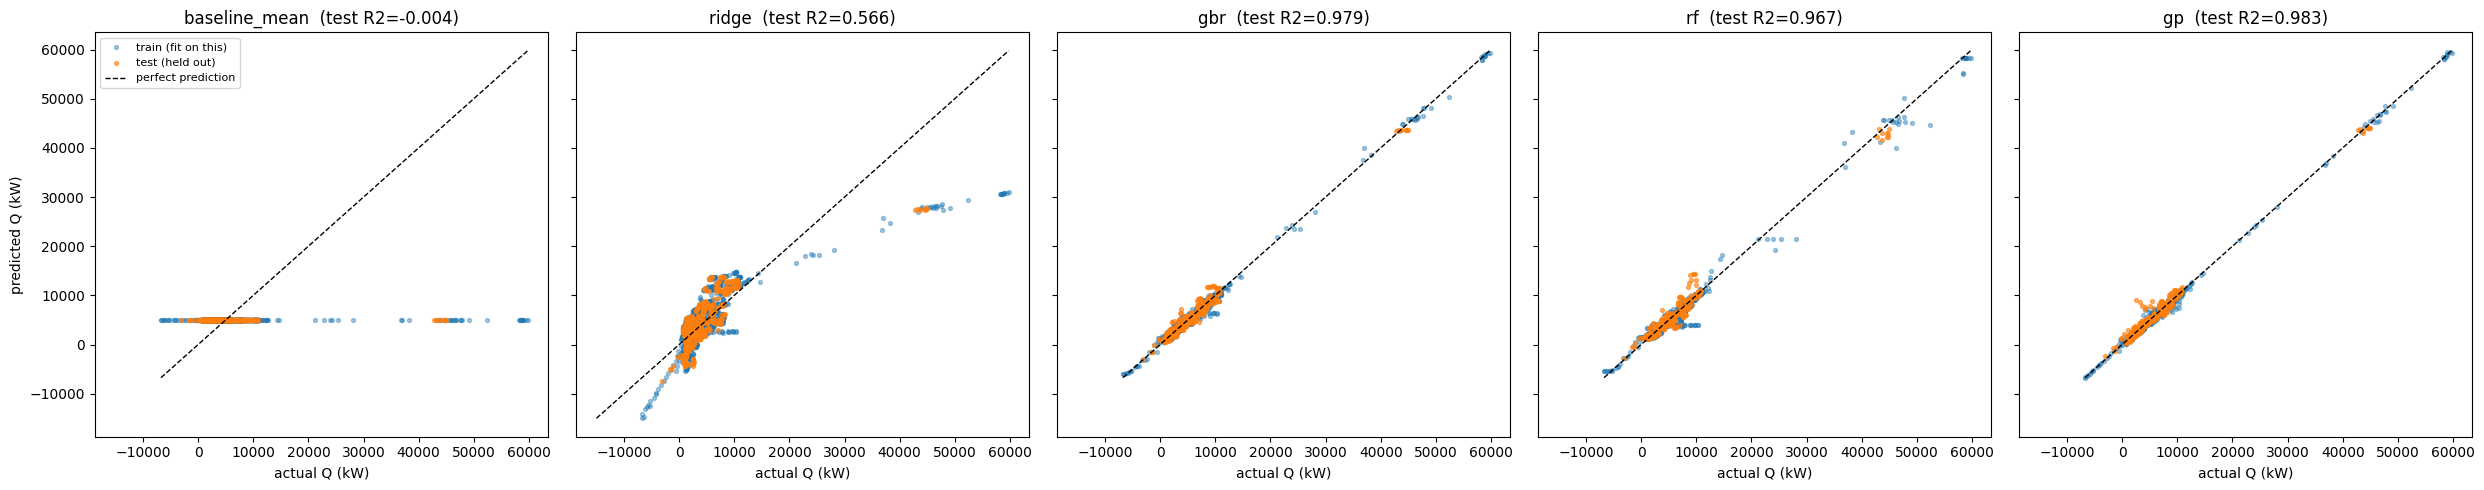

In [20]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    ax.scatter(y_train, model.predict(X_train), s=8, alpha=0.4, color='tab:blue', label='train (fit on this)')
    ax.scatter(y_test, model.predict(X_test), s=8, alpha=0.6, color='tab:orange', label='test (held out)')
    lims = [min(y_full.min(), model.predict(X_full).min()), max(y_full.max(), model.predict(X_full).max())]
    ax.plot(lims, lims, 'k--', lw=1, label='perfect prediction')
    ax.set_title(f'{name}  (test R2={comparison_df.loc[name, "held_out_test_r2"]:.3f})')
    ax.set_xlabel('actual Q (kW)')
axes[0].set_ylabel('predicted Q (kW)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3a_model_comparison_scatter.png'), bbox_inches='tight')
plt.show()

In [21]:
best_name = comparison_df['held_out_test_r2'].idxmax()
print(f'Selected model: {best_name}')
print(comparison_df.loc[[best_name]].round(4))
if comparison_df.loc[best_name, 'overfit_gap'] > 0.05:
    print(f'\nNOTE: train-test R2 gap = {comparison_df.loc[best_name, "overfit_gap"]:.3f} '
          f'-- some overfitting present, interpret the deviation signal from this model with more caution.')

# Refit the selected model on the FULL baseline pool (train+test, i.e. all days 0-30) for deployment --
# the train/test split above is only to pick the model and measure its extrapolation error; once chosen,
# using all available clean-baseline data gives the best final model for section 4.
best_model = models[best_name]
best_model.fit(X_full, y_full)

Selected model: gp
       train_r2  held_out_test_r2  test_mae_kW  group_cv_r2_by_hx  overfit_gap
model                                                                         
gp       0.9965            0.9834     408.5789             -0.114       0.0131


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](6,)","[228.2 ,128.87,198.73, 0.86, 0.35, 0.77]"


## 4. Per-Timestamp Deviation Signal (Full History)

Apply the fitted clean-baseline model to **every** NORMAL-operation
timestamp per HX (not just the training window) to get a dense fouling
signal:

```
deviation = predicted_Q (assumes clean) - actual_Q
```

Positive and growing deviation = actual duty running below what the
clean-state model expects for that flow/inlet-temp combination = fouling
(directly comparable in sign convention to `2b`'s `Q_drop_pct`). This should
reset toward ~0 immediately after each clean event -- that reset is the
primary sanity check for this notebook (there's no ground-truth Rf to
validate against directly, same limitation Horn's thesis flags for real
facility data).

In [22]:
deviation_rows = []
for hx, cfg in HX_CONFIG.items():
    flow_tag, in_tag, out_tag = cfg['cold_flow'], cfg['cold_in'], cfg['cold_out']
    hot_tag = HOT_IN_TAG.get(hx)
    days_col, run_col, event_col, q_col = f'{hx}_days_on_duty', f'{hx}_run_id', f'{hx}_event_type', f'{hx}_Q'
    if days_col not in feat.columns or q_col not in feat.columns or not hot_tag or hot_tag not in feat.columns:
        continue
    cols_needed = ['Timestamp', flow_tag, in_tag, out_tag, hot_tag, days_col, run_col, event_col, q_col]
    sub = feat[[c for c in cols_needed if c in feat.columns]].copy()
    sub = sub.merge(op_state[['Timestamp', hx]], on='Timestamp', how='left')
    sub = sub[sub[hx] == 'NORMAL'].dropna(subset=[flow_tag, in_tag, out_tag, hot_tag, q_col])
    if len(sub) == 0:
        continue
    sub = sub.rename(columns={flow_tag: 'cold_flow', in_tag: 'cold_in', out_tag: 'cold_out',
                               hot_tag: 'hot_in', days_col: 'days_on_duty', run_col: 'run_id',
                               event_col: 'event_type', q_col: 'Q'})
    row = static_df[static_df['HX'] == hx].iloc[0]
    sub['chain_position'] = row['chain_position']
    sub['hot_end'] = row['hot_end']
    for gcol in [c for c in pooled.columns if c.startswith('group_')]:
        sub[gcol] = 1 if row['group'] == gcol.replace('group_', '') else 0

    Xh = sub[feature_cols].values
    sub['predicted_Q'] = best_model.predict(Xh)
    sub['deviation'] = sub['predicted_Q'] - sub['Q']
    sub['HX'] = hx
    deviation_rows.append(sub[['Timestamp', 'HX', 'cold_flow', 'cold_in', 'cold_out', 'Q',
                                'predicted_Q', 'deviation', 'days_on_duty', 'run_id', 'event_type']])

deviation_df = pd.concat(deviation_rows, ignore_index=True)
print(f'Deviation signal: {deviation_df.shape[0]} rows across {deviation_df["HX"].nunique()} HX')
deviation_df.head()

Deviation signal: 28113 rows across 15 HX


,Timestamp,HX,cold_flow,cold_in,cold_out,Q,predicted_Q,deviation,days_on_duty,run_id,event_type
0,2021-01-01,E101AB,176.645412,36.785905,85.917345,3961.409954,4187.044722,225.634768,0.0,1,DATA_START
1,2021-01-02,E101AB,163.238981,38.276132,88.100475,3725.514346,4277.394113,551.879767,1.0,1,DATA_START
2,2021-01-03,E101AB,156.561324,38.026126,89.541006,3694.349416,4215.678210,521.328794,2.0,1,DATA_START
3,2021-01-04,E101AB,162.580204,38.009552,89.416143,3828.311391,4270.980948,442.669557,3.0,1,DATA_START
4,2021-01-05,E101AB,163.187989,37.945464,89.219629,3832.724264,4268.596852,435.872589,4.0,1,DATA_START


## 5. Sanity Check: Deviation Should Reset After Cleaning

Green shading = train window (days 0-21 of that clean cycle, used to *fit*
the model); orange shading = held-out test window (days 22-30, used only to
*score* the model); unshaded = deployment region (day 30+, where the model
has never seen data and is purely predicting/extrapolating -- this is where
the actual fouling deviation signal comes from).

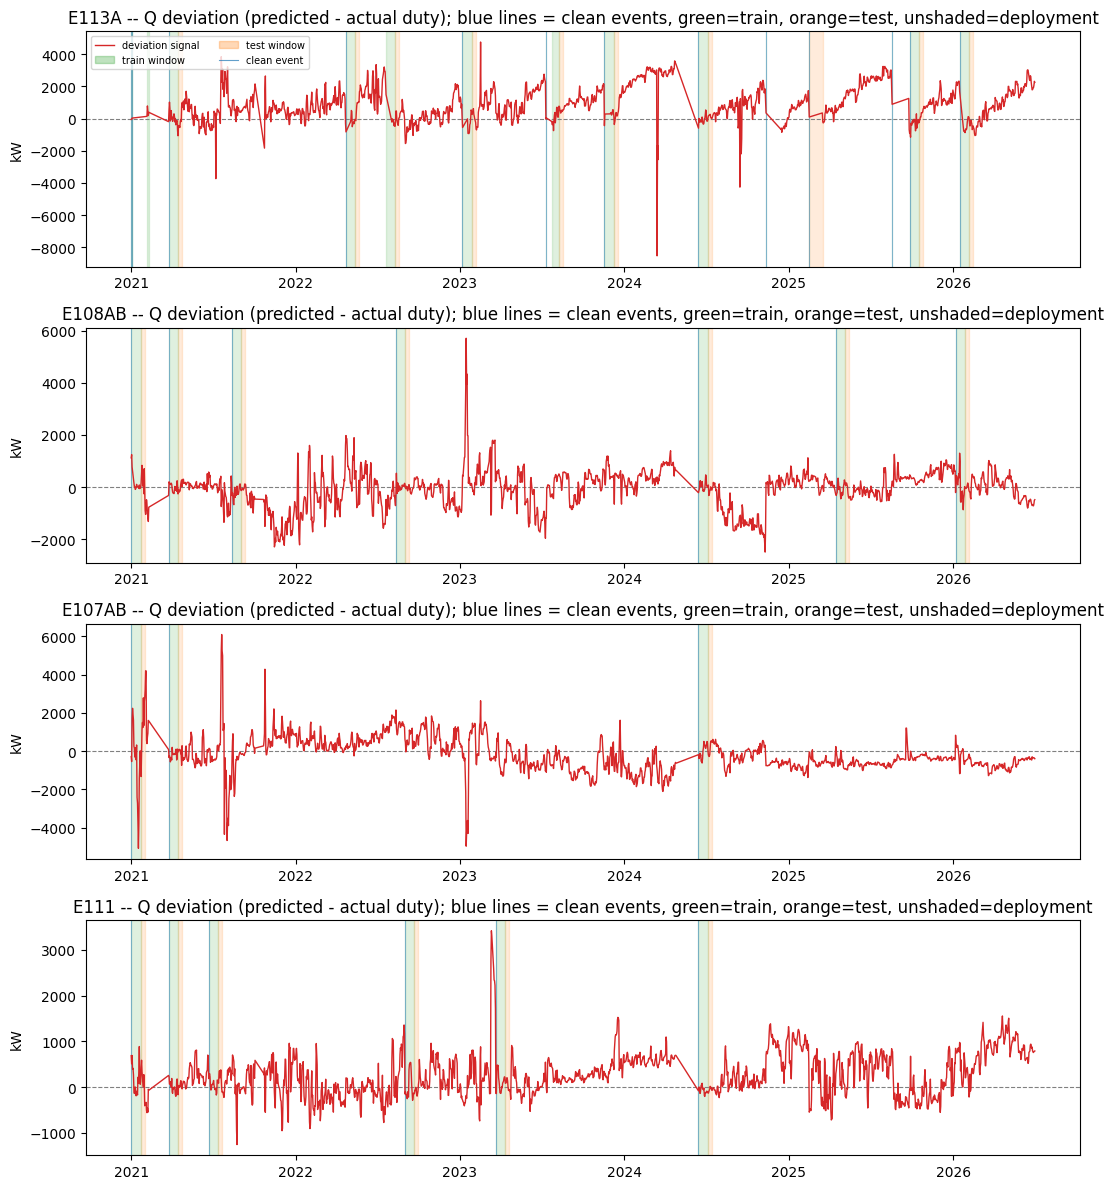

In [23]:
check_hx = ['E113A', 'E108AB', 'E107AB', 'E111']
fig, axes = plt.subplots(len(check_hx), 1, figsize=(11, 3 * len(check_hx)), sharex=False)
for ax, hx in zip(axes, check_hx):
    d = deviation_df[deviation_df['HX'] == hx].sort_values('Timestamp')
    ax.plot(d['Timestamp'], d['deviation'], color='tab:red', lw=1, zorder=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=2)

    for run_id, rg in d.groupby('run_id'):
        rg = rg.sort_values('Timestamp')
        start = rg['Timestamp'].iloc[0]
        train_rows = rg[rg['days_on_duty'] <= TRAIN_CUTOFF_DAYS]
        train_end = train_rows['Timestamp'].iloc[-1] if len(train_rows) else start
        baseline_rows = rg[rg['days_on_duty'] <= BASELINE_WINDOW_DAYS]
        baseline_end = baseline_rows['Timestamp'].iloc[-1] if len(baseline_rows) else start
        ax.axvspan(start, train_end, color='tab:green', alpha=0.15, zorder=1)
        if baseline_end > train_end:
            ax.axvspan(train_end, baseline_end, color='tab:orange', alpha=0.15, zorder=1)

    run_starts = d[d['days_on_duty'] == 0]
    for ts in run_starts['Timestamp']:
        ax.axvline(ts, color='tab:blue', lw=0.8, alpha=0.5, zorder=2)
    ax.set_title(f'{hx} -- Q deviation (predicted - actual duty); blue lines = clean events, '
                 f'green=train, orange=test, unshaded=deployment')
    ax.set_ylabel('kW')

handles = [plt.Line2D([0], [0], color='tab:red', lw=1, label='deviation signal'),
           plt.Rectangle((0, 0), 1, 1, color='tab:green', alpha=0.3, label='train window'),
           plt.Rectangle((0, 0), 1, 1, color='tab:orange', alpha=0.3, label='test window'),
           plt.Line2D([0], [0], color='tab:blue', lw=0.8, alpha=0.7, label='clean event')]
axes[0].legend(handles=handles, loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3a_deviation_sanity_check.png'), bbox_inches='tight')
plt.show()

## 6. Save Output

In [24]:
out_path = DATA_DIR + r'\Q_Deviation_Signal.csv'
deviation_df.to_csv(out_path, index=False)
print(f'Wrote {out_path}', deviation_df.shape)
print(f'Model used: {best_name}')
print(comparison_df.round(4))

Wrote C:\Desktop\Bangchak Internship 2026\Data\Q_Deviation_Signal.csv (28113, 11)
Model used: gp
               train_r2  held_out_test_r2  test_mae_kW  group_cv_r2_by_hx  \
model                                                                       
baseline_mean    0.0000           -0.0036    2836.6365            -0.1083   
ridge            0.6440            0.5665    2626.0295            -0.1944   
gbr              0.9927            0.9792     559.3536             0.0573   
rf               0.9803            0.9671     668.7328             0.0592   
gp               0.9965            0.9834     408.5789            -0.1140   

               overfit_gap  
model                       
baseline_mean       0.0036  
ridge               0.0776  
gbr                 0.0135  
rf                  0.0132  
gp                  0.0131  


## 7. Limitations

- **Q-based pooling generalizes far worse across HX than the temperature
  version did** -- `group_cv_r2_by_hx` is now *negative* for ridge (-0.154)
  and gbr (-0.013), versus ~0.92 when the target was `cold_out`. Reason: Q's
  absolute scale varies hugely by HX size/duty (E113A ~7600 kW vs E101AB
  ~4300 kW), unlike temperature which sits in a comparable ~70-260 degC band
  for every HX regardless of size. A model trained without ever seeing a
  given HX's own Q scale predicts badly for it. **This does not invalidate
  the deployed signal**, because `best_model` is refit on the full pool
  (`X_full`/`y_full`, section 3's last cell) which includes every HX's own
  baseline data before section 4 scores that same HX -- but it does mean
  this approach would need a 17th HX's own post-clean baseline data before
  it could be trusted for that HX, i.e. it is *not* a few-shot/zero-shot
  method the way the temperature version came closer to being.
- **Held-out test R2/MAE (within-HX, same-HX extrapolation) still look
  reasonable** -- gbr test R2=0.911, test MAE=455 kW -- so the deviation
  signal for HX the model *has* seen its own baseline for (all 15 HX
  currently in the dataset) should still be usable.
- **Hot-side duty is not a feature** -- omitted because no reliable per-HX
  hot-side flow exists in this dataset (shared/switched residue path). The
  clean-baseline model implicitly assumes hot-side conditions during each
  30-day post-clean window are "typical"; a crude-quality shift during that
  window would bias the baseline itself, not just the later deviation.
- **Held-out test window is only 9 days (22-30) per clean cycle** -- enough
  to catch gross overfitting but not a long-horizon extrapolation test; the
  deployment region in section 5 extends to hundreds of days past what any
  model has been scored against.
- **No ground-truth Rf** -- unlike the simulated data in Horn's thesis, there
  is no way to calibrate `deviation` to a physical fouling-resistance value
  here. The reset-to-~0-after-cleaning check in section 5 is the only
  available validation, and it is visibly noisier for Q than it was for
  temperature (E107AB/E111 in particular don't show a clean sawtooth).
- **baseline_mean/GP added 2026-07-13 to widen the comparison, not to fix the
  cross-HX generalization gap above** -- `baseline_mean` (group-average duty,
  ignoring all operating-condition features) is the honest floor every real model
  should clear; if `group_cv_r2_by_hx` for ridge/gbr/rf is already negative, a
  R2=0 dummy is BEATING them at cross-HX generalization, which the printed
  comparison table now makes visible rather than only implying. `gp` adds a
  predictive-uncertainty band (not evaluated here, but available via
  `models['gp'].predict(X, return_std=True)`) that is useful for flagging
  low-confidence HX in the evidence tab; it is still selected/deployed by the
  same `held_out_test_r2` criterion as the others, so it only becomes
  `best_model` if it genuinely wins on that metric, not by default.
- **Now Q-based, so directly comparable to `2b`** -- `Q` here is the exact
  same quantity `2b`'s `Q_drop_pct`/`mean_Q_norm` are built from, just with
  an ML baseline that varies per-timestamp with `cold_flow`/`cold_in`
  instead of `2b`'s single flat per-run mean. The two should mostly agree in
  *direction*; `3b` can treat large disagreement in *magnitude* as a
  modelling-uncertainty flag rather than picking one over the other.

---

# Part 3 · Time-to-Clean Prediction

*(merged from the former `07_forecasting.ipynb`, 2026-07-19 — content unchanged, only the
redundant DE-STEP-HEADER/title boilerplate was folded into this notebook's own header above.)*

**Purpose:** turn Part 2's Q-duty deviation signal into "how many days until this HX needs
cleaning", per HX, so `13_cleaning_plan_optimization.ipynb` can build a schedule.


In [25]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from src.domain.config import CPHT_1_HX, CPHT_2_HX

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

dev = pd.read_csv(DATA_DIR + r'\Q_Deviation_Signal.csv', parse_dates=['Timestamp'])
AS_OF_DATE = dev['Timestamp'].max()
print(f'"Now" reference (last available data point): {AS_OF_DATE.date()}')

# Effort tiers -- SINGLE SOURCE: bypass_config.py, parsed from the real plant file
# (Data/list bypass Cleaning Heat Exchanger.xlsx). 2026-07-12 fix: the old hardcoded
# lists here directly contradicted that file (see bypass_config.py docstring).
from src.domain.bypass import BYPASS_CONFIG
from src.domain.config import PARALLEL_SHELL_GROUPS
_SWAP = {a for pair in PARALLEL_SHELL_GROUPS for a in pair}

def effort_tier(hx):
    if hx in _SWAP:
        return 'SWAP_CAPABLE'
    mode = BYPASS_CONFIG.get(hx, {}).get('online_mode', 'none')
    return {'full': 'ONLINE_FULL', 'partial': 'ONLINE_PARTIAL', 'none': 'TAM_ONLY'}[mode]

NEXT_TAM_DATE = pd.Timestamp('2028-06-01')  # PLACEHOLDER -- confirm exact date before scheduling on this
print(f'Next TAM (placeholder): {NEXT_TAM_DATE.date()} -- confirm exact date before using for scheduling')

"Now" reference (last available data point): 2026-07-01


Next TAM (placeholder): 2028-06-01 -- confirm exact date before using for scheduling


## 1. Historical Clean-Trigger Thresholds

A real clean event is a run boundary where the *new* run's `event_type` is
`SWITCH` or `TAM`. The trigger level is the deviation on the last day of the
*preceding* run (the peak fouling state right before it was reset).

**Reliability check added after first pass:** several HX show clean events
with a **negative** trigger deviation (model shows no fouling signal at the
moment of the "clean") -- e.g. E112AB ranges from -15.1 to +4.5 across just
4 events, E104's two events are -11.4 and +2.2. A clean happening while the
model shows no positive fouling buildup is very likely a **non-fouling-driven
shell swap** (spare rotation, e.g. the documented E113A<->E112C pair),
not evidence that "slightly fouled" is an acceptable trigger level. Using
those events as-is would produce a threshold below the HX's current healthy
operating deviation, which is exactly what happened in the first pass (8 of
15 HX showed `days_to_threshold = 0` immediately).

**Fix:** only positive trigger deviations are treated as fouling-driven
clean-trigger evidence. HX with zero positive trigger events fall back to
the group median of *other* HX that do have at least one positive trigger
event.

In [26]:
trigger_rows = []
for hx, g in dev.groupby('HX'):
    g = g.sort_values('Timestamp').reset_index(drop=True)
    run_change = g['run_id'] != g['run_id'].shift(1)
    real_clean_starts = g[run_change & g['event_type'].isin(['SWITCH', 'TAM'])]
    for idx in real_clean_starts.index:
        if idx == 0:
            continue
        trigger_rows.append({'HX': hx, 'clean_date': g.loc[idx, 'Timestamp'],
                              'trigger_deviation': g.loc[idx - 1, 'deviation']})

triggers = pd.DataFrame(trigger_rows)
triggers['fouling_driven'] = triggers['trigger_deviation'] > 0

reliability = triggers.groupby('HX').agg(
    n_total=('trigger_deviation', 'count'),
    n_positive=('fouling_driven', 'sum'),
)
reliability['pct_non_fouling_driven'] = 1 - reliability['n_positive'] / reliability['n_total']
self_threshold = (triggers[triggers['fouling_driven']]
                   .groupby('HX')['trigger_deviation'].median().rename('self_threshold'))

print(f'{len(triggers)} historical real-clean events across {reliability.shape[0]} HX '
      f'({triggers["fouling_driven"].sum()} classified fouling-driven, i.e. positive deviation)')
reliability.join(self_threshold).sort_values('pct_non_fouling_driven', ascending=False)

66 historical real-clean events across 15 HX (52 classified fouling-driven, i.e. positive deviation)


,n_total,n_positive,pct_non_fouling_driven,self_threshold
HX,,,,
E105AB,3,1,0.666667,1058.122017
E108AB,6,3,0.500000,616.426569
E107AB,2,1,0.500000,1578.440929
E109AB,2,1,0.500000,200.234062
E101CD,3,2,0.333333,354.631340
E111,5,4,0.200000,928.402348
E112AB,10,8,0.200000,1162.089307
E102,6,5,0.166667,95.843718
E113A,15,13,0.133333,1220.400025


In [27]:
all_hx = dev['HX'].unique()
group_of = {hx: ('CPHT-1' if hx in CPHT_1_HX else 'CPHT-2') for hx in all_hx}
group_median = self_threshold.rename_axis('HX').reset_index()
group_median['group'] = group_median['HX'].map(group_of)
group_median = group_median.groupby('group')['self_threshold'].median()

threshold_rows = []
for hx in all_hx:
    n_pos = reliability['n_positive'].get(hx, 0)
    if hx in self_threshold.index:
        conf = 'high' if n_pos >= 3 else 'medium'
        threshold_rows.append({'HX': hx, 'threshold': self_threshold[hx],
                                'threshold_source': 'own_history', 'threshold_confidence': conf,
                                'n_fouling_driven_events': int(n_pos)})
    else:
        grp = group_of[hx]
        threshold_rows.append({'HX': hx, 'threshold': group_median[grp],
                                'threshold_source': f'{grp}_group_median (no own fouling-driven clean observed)',
                                'threshold_confidence': 'low', 'n_fouling_driven_events': int(n_pos)})
threshold_df = pd.DataFrame(threshold_rows)
threshold_df.sort_values('threshold_confidence')

,HX,threshold,threshold_source,threshold_confidence,n_fouling_driven_events
3,E102,95.843718,own_history,high,5
5,E104,161.728034,own_history,high,4
9,E108AB,616.426569,own_history,high,3
12,E111,928.402348,own_history,high,4
13,E112AB,1162.089307,own_history,high,8
14,E113A,1220.400025,own_history,high,13
0,E101AB,568.286117,own_history,medium,2
1,E101CD,354.631340,own_history,medium,2
2,E101EF,3001.652791,own_history,medium,2
4,E103AB,1684.900521,own_history,medium,2


## 2. Current State and Fouling Rate

Rate is fit on the current open run's `(days_on_duty, deviation)`. If fewer
than 10 points are available in the current run (too new to trust a slope),
fall back to the most recent *completed* run's slope for that HX.

In [28]:
MIN_POINTS_FOR_RATE = 10

def fit_rate(sub):
    """Linear slope of Q-duty deviation vs days_on_duty (kW/day). NaN if <2 points."""
    if len(sub) < 2:
        return np.nan
    slope, _ = np.polyfit(sub['days_on_duty'], sub['deviation'], 1)
    return slope

state_rows = []
for hx, g in dev.groupby('HX'):
    g = g.sort_values('Timestamp').reset_index(drop=True)
    current_run_id = g['run_id'].iloc[-1]
    current_run = g[g['run_id'] == current_run_id]
    current_deviation = g['deviation'].iloc[-1]
    current_days = g['days_on_duty'].iloc[-1]

    if len(current_run) >= MIN_POINTS_FOR_RATE:
        rate = fit_rate(current_run)
        rate_source = 'current_run'
    else:
        prior_runs = g[g['run_id'] < current_run_id]
        if prior_runs.empty:
            rate, rate_source = np.nan, 'insufficient_data'
        else:
            last_run_id = prior_runs['run_id'].max()
            rate = fit_rate(prior_runs[prior_runs['run_id'] == last_run_id])
            rate_source = 'previous_completed_run'

    state_rows.append({'HX': hx, 'current_deviation': current_deviation,
                        'current_days_on_duty': current_days,
                        'rate_kW_per_day': rate, 'rate_source': rate_source,
                        'n_points_current_run': len(current_run)})

state_df = pd.DataFrame(state_rows)
state_df

,HX,current_deviation,current_days_on_duty,rate_kW_per_day,rate_source,n_points_current_run
0,E101AB,393.180905,747.0,-1.217289,current_run,748
1,E101CD,148.456945,747.0,0.724546,current_run,748
2,E101EF,2190.492202,582.0,2.134553,current_run,583
3,E102,248.827892,702.0,1.055068,current_run,703
4,E103AB,630.647840,747.0,1.881255,current_run,748
5,E104,2225.080777,443.0,4.273980,current_run,444
6,E105AB,-465.541585,103.0,-3.667337,current_run,104
7,E106AB,-315.419299,747.0,-1.127184,current_run,748
8,E107AB,-398.824025,747.0,-0.482074,current_run,748
9,E108AB,-485.399313,176.0,-3.563876,current_run,177


## 2b. Cross-Check Against Notebook 02's Rf-Based Rate

NB04's `rate_kW_per_day` above comes from an ML clean-baseline model of Q-duty --
a nonlinear proxy, not a physically additive quantity, and its leave-HX-out CV
generalization is near zero/negative (see Part 2 Limitations). Notebook 02 /
`pipeline/compute_fouling_rate.py` fit an independent, more rigorous rate directly
on Rf (fouling resistance, physically additive) via Theil-Sen + AIC curve
selection, with its own reliability gate (`reliable`, `rate_flag`). That pathway
already cross-checks Rf against U_relative internally -- it does **not** check
against this notebook's Q-deviation slope, so that comparison is new here.

Both signals use the same sign convention for "getting worse": `rate_kW_per_day > 0`
means the Q-shortfall is growing, `dRf_per_day > 0` means fouling resistance is
growing -- so a physically consistent HX should show the **same sign** on both.
Only NB02's `reliable == True` runs are used as the comparison baseline (an
unreliable Rf fit is not a trustworthy yardstick either).


In [ ]:
# Load NB02/pipeline's authoritative Rf-based rate (Theil-Sen + AIC race, reliability-gated)
# and cross-check its sign against this notebook's own Q-deviation slope above.
rf_by_run = pd.read_csv(DATA_DIR + r'\Fouling_Rate_By_Run.csv', parse_dates=['Run_start'])

# Latest RELIABLE run per HX -- an old or gated-out run's sign isn't a meaningful
# check against NB04's "current state" rate.
rf_latest = (rf_by_run[rf_by_run['reliable']]
             .sort_values('Run_start')
             .groupby('HX')
             .tail(1)
             .set_index('HX')[['dRf_per_day', 'R2_model', 'rate_flag', 'Run_start']]
             .rename(columns={'dRf_per_day': 'rf_dRf_per_day', 'R2_model': 'rf_R2_model',
                               'rate_flag': 'rf_rate_flag', 'Run_start': 'rf_run_start'}))

state_df = state_df.merge(rf_latest, on='HX', how='left')

def _sign(x):
    if pd.isna(x):
        return np.nan
    if abs(x) < 1e-12:
        return 0
    return 1 if x > 0 else -1

def _rf_agreement(row):
    if pd.isna(row['rf_dRf_per_day']):
        return 'no_reliable_rf_data'
    if pd.isna(row['rate_kW_per_day']):
        return 'no_q_rate_data'
    return 'agree' if _sign(row['rate_kW_per_day']) == _sign(row['rf_dRf_per_day']) else 'disagree'

state_df['rf_cross_check'] = state_df.apply(_rf_agreement, axis=1)

print('Rf cross-check (vs notebook 02 / pipeline/compute_fouling_rate.py, reliable runs only):')
print(state_df['rf_cross_check'].value_counts())

n_disagree = (state_df['rf_cross_check'] == 'disagree').sum()
if n_disagree:
    print(f'{chr(10)}WARNING: {n_disagree} HX where the Q-deviation slope direction disagrees with '
          f'the Rf-based rate direction -- treat their days-to-clean projection with extra caution:')
    print(state_df.loc[state_df['rf_cross_check'] == 'disagree',
                        ['HX', 'rate_kW_per_day', 'rf_dRf_per_day', 'rf_rate_flag']])
state_df


## 3. Days-to-Threshold Projection

`days_to_threshold = (threshold - current_deviation) / rate`, only
meaningful when `rate > 0` (fouling actively worsening). Non-positive rate
or missing rate data means the horizon can't be projected -- reported as
`>12 months` (not a claim that fouling has stopped, just that the model has
no basis to project a nearer date).

In [ ]:
HORIZON_DAYS = 365

result = state_df.merge(threshold_df, on='HX', how='left')
result['effort_tier'] = result['HX'].map(effort_tier)

def project_days(row):
    if pd.isna(row['rate_kW_per_day']) or row['rate_kW_per_day'] <= 0:
        return np.nan
    remaining = row['threshold'] - row['current_deviation']
    if remaining <= 0:
        return 0.0  # already at/above its own historical trigger level
    return remaining / row['rate_kW_per_day']

result['days_to_threshold_raw'] = result.apply(project_days, axis=1)
result['days_to_threshold'] = result['days_to_threshold_raw'].clip(upper=HORIZON_DAYS)
result['beyond_horizon'] = result['days_to_threshold_raw'].isna() | (result['days_to_threshold_raw'] > HORIZON_DAYS)
result['projected_need_by_date'] = result.apply(
    lambda r: AS_OF_DATE + pd.Timedelta(days=r['days_to_threshold']) if not r['beyond_horizon'] else pd.NaT,
    axis=1
)

# TAM constraint: flag TAM_ONLY HX whose projected need-by date falls before the next TAM
result['at_risk_before_tam'] = (
    (result['effort_tier'] == 'TAM_ONLY') &
    (~result['beyond_horizon']) &
    (result['projected_need_by_date'] < NEXT_TAM_DATE)
)

cols = ['HX', 'effort_tier', 'current_deviation', 'threshold', 'threshold_source',
        'threshold_confidence', 'rate_kW_per_day', 'rate_source', 'days_to_threshold',
        'beyond_horizon', 'projected_need_by_date', 'at_risk_before_tam',
        'rf_cross_check', 'rf_dRf_per_day', 'rf_rate_flag']
result_sorted = result[cols].sort_values('days_to_threshold', na_position='last')
result_sorted

## 4. Summary Plot

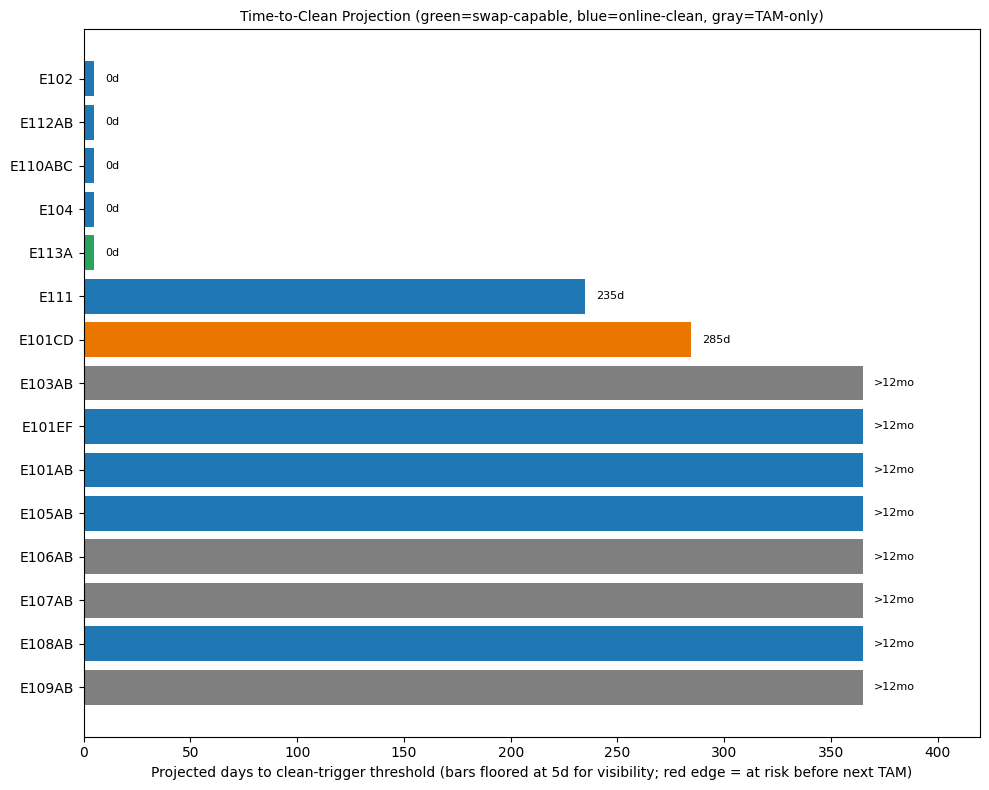

In [30]:
plot_df = result_sorted.copy()
plot_df['plot_days'] = plot_df['days_to_threshold'].fillna(HORIZON_DAYS)
DISPLAY_FLOOR = 5  # visual floor only, so "needs clean now" bars are visible -- not a real value
plot_df['plot_days_display'] = plot_df['plot_days'].clip(lower=DISPLAY_FLOOR)
tier_colors = {'SWAP_CAPABLE': '#2ca25f', 'ONLINE_FULL': '#1f77b4', 'ONLINE_PARTIAL': '#EA7600', 'TAM_ONLY': '#7f7f7f'}
colors = [tier_colors[t] for t in plot_df['effort_tier']]
risk_edge = ['red' if r else 'none' for r in plot_df['at_risk_before_tam']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['HX'], plot_df['plot_days_display'], color=colors, edgecolor=risk_edge, linewidth=2)
for bar, days, beyond in zip(bars, plot_df['days_to_threshold'], plot_df['beyond_horizon']):
    label = '>12mo' if beyond or pd.isna(days) else f'{days:.0f}d'
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=8)
ax.set_xlabel('Projected days to clean-trigger threshold (bars floored at 5d for visibility; red edge = at risk before next TAM)')
ax.set_title('Time-to-Clean Projection (green=swap-capable, blue=online-clean, gray=TAM-only)', fontsize=10)
ax.set_xlim(0, HORIZON_DAYS * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3b_time_to_clean.png'), bbox_inches='tight')
plt.show()

## 5. Save Output

In [31]:
out_path = DATA_DIR + r'\Time_To_Clean_Prediction.csv'
result_sorted.to_csv(out_path, index=False)
print(f'Wrote {out_path}', result_sorted.shape)

n_at_risk = result_sorted['at_risk_before_tam'].sum()
if n_at_risk:
    print(f'\nWARNING: {n_at_risk} TAM_ONLY HX projected to need cleaning before the next TAM window:')
    print(result_sorted.loc[result_sorted['at_risk_before_tam'], ['HX', 'projected_need_by_date']])

Wrote C:\Desktop\Bangchak Internship 2026\Data\Time_To_Clean_Prediction.csv (15, 12)


## 6. Limitations

- **Rate is a straight-line extrapolation of the current run** -- real
  fouling can accelerate (crude-quality shift, coking onset) or plateau
  (asymptotic fouling curve), neither of which a linear fit captures. Treat
  `days_to_threshold` as a planning-horizon estimate, not a guarantee.
- **Self-threshold from very few historical events is noisy** -- HX with
  only 1-2 real-clean events in the dataset have a threshold based on that
  many data points; the group-median fallback for HX with *zero* events is
  weaker still.
- **`NEXT_TAM_DATE` is a placeholder (`2028-06-01`)** -- must be replaced
  with the confirmed turnaround date before `at_risk_before_tam` flags are
  used for real scheduling decisions.
- Rate and threshold both come from the `3a` deviation signal only; `2b`'s
  independent `U_relative`/`Rf_run` trend is not cross-checked here -- `3c`
  should surface disagreement between the two as a confidence signal.